# Week-4


Processing: Grand Caricaie  marsh dominated by Cladietum marisci, not mown  ClControl2


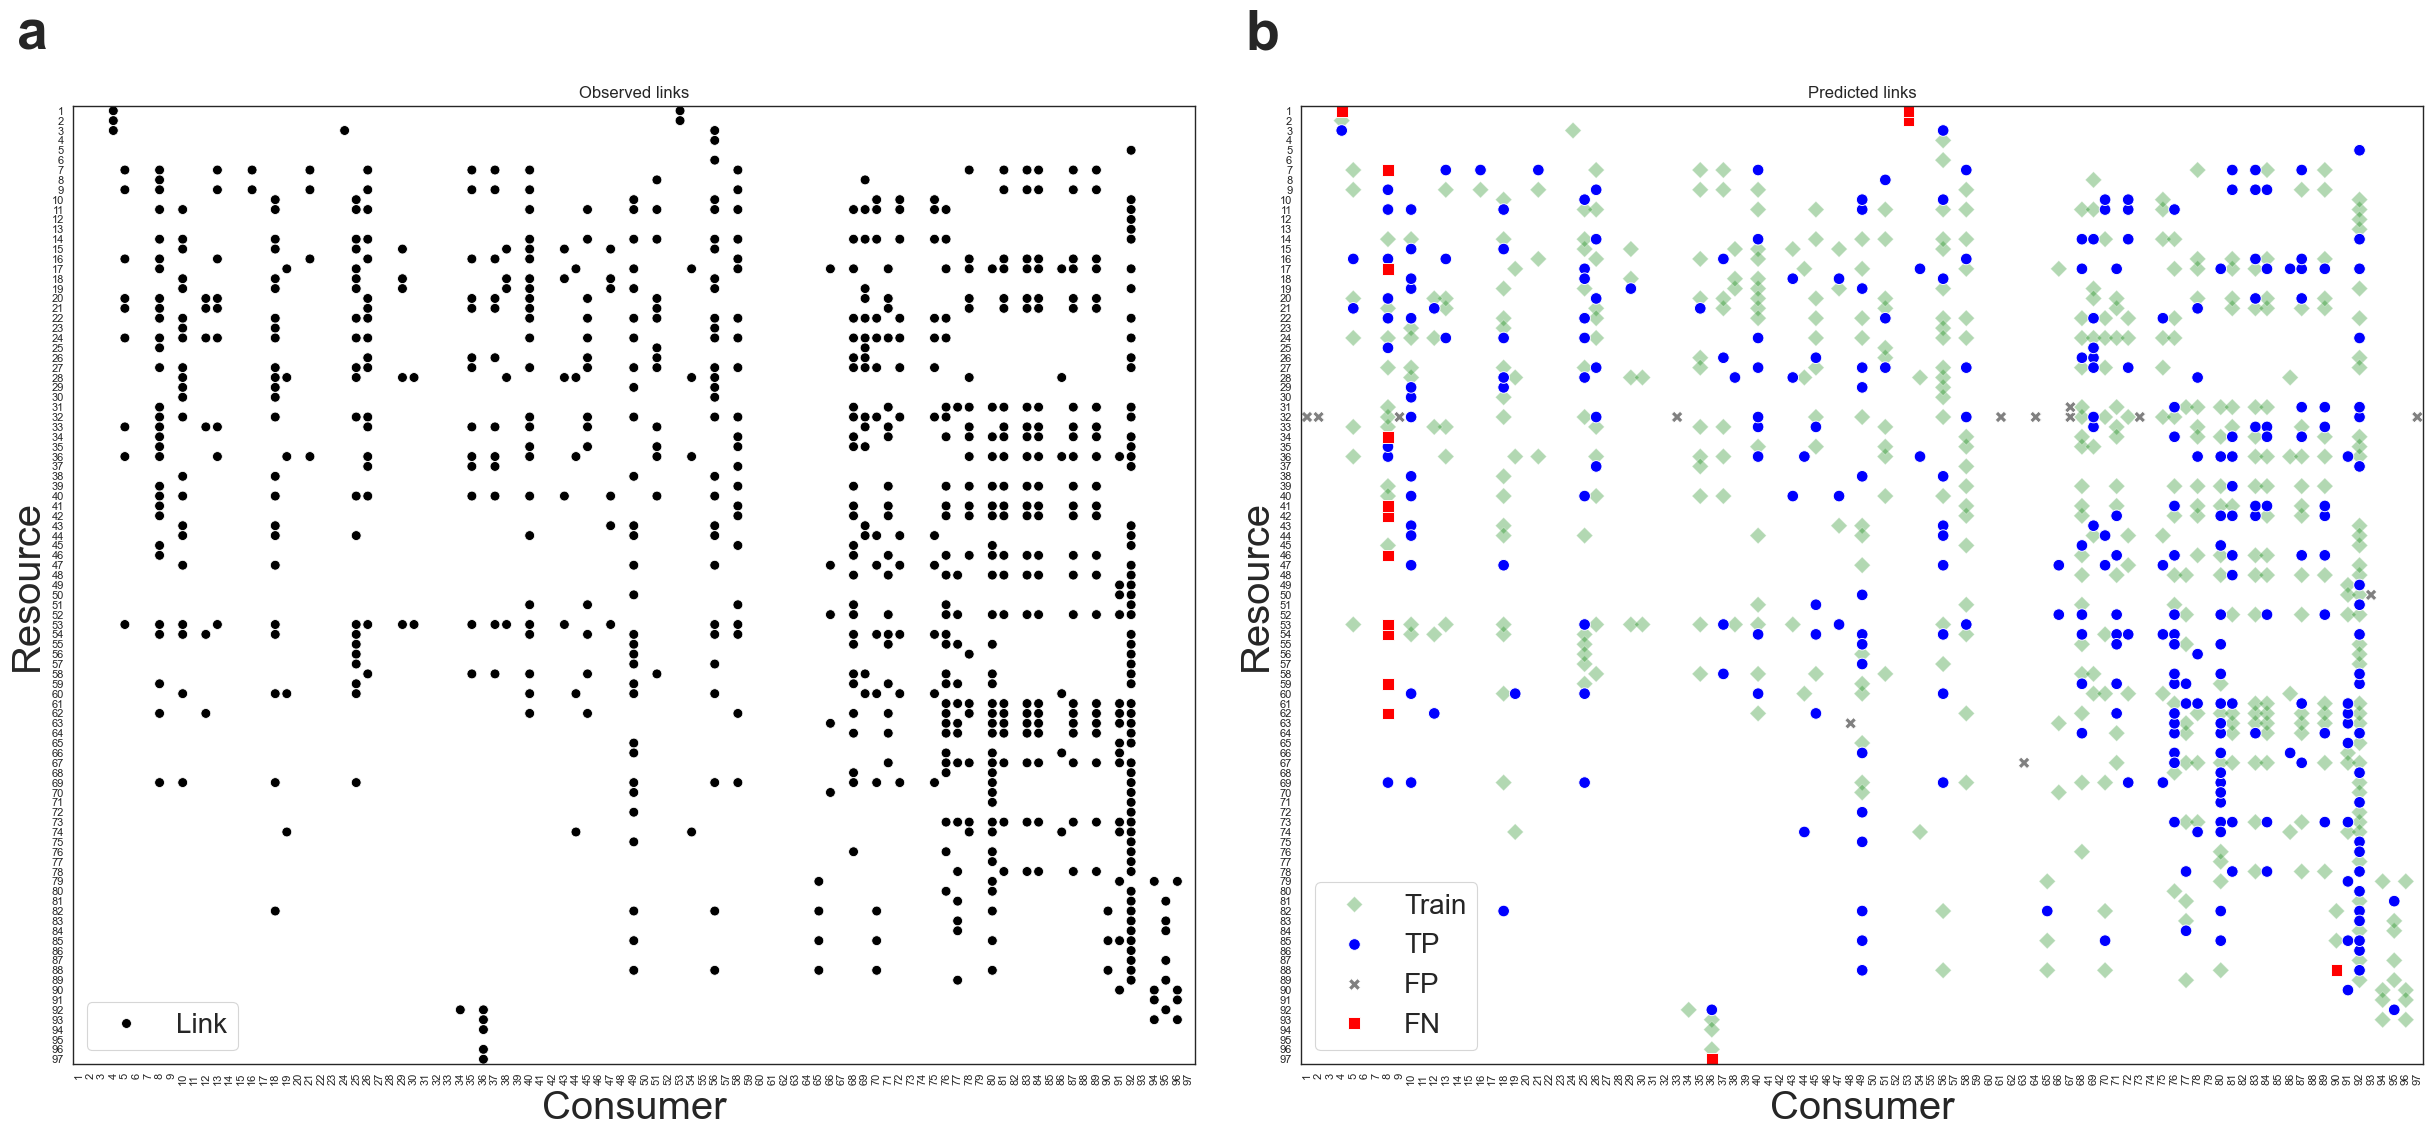

In [19]:
import os
import re
import scipy.io
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix, csr_matrix

# Apply seaborn style
sns.set_theme(context="paper", style="white", font_scale=3)

# =========================
# Figure controls (flags)
# =========================
MAX_PLOTS = 1

SHOW_TITLES = True          # toggle subplot titles on/off
SHOW_TICKS = True           # toggle tick labels + tick marks on/off

# Paper-friendly labels (only used if SHOW_TITLES=True)
TITLE_LEFT = "Observed links"
TITLE_RIGHT = "Predicted links"

# Paper-friendly axis labels (optional: keep short)
XLAB = "Consumer"
YLAB = "Resource"

# =========================
# NEW: numeric axis labels + species key printing
# =========================
USE_NUMERIC_AXIS_LABELS = True   # axis shows 1..N instead of species names
PRINT_SPECIES_KEY = False         # print Number <-> Species mapping
EXPORT_SPECIES_KEY_FILE = False
SPECIES_KEY_DIR = "./species_keys"   # folder to save keys
SPECIES_KEY_FORMAT = "csv"           # "tsv" (best for Word) or "csv"

# =========================
# NEW: plot a specific foodweb (optional)
# =========================
# Set to None to run as before.
# Or set to a string like: "ChesapeakeBay" or "ChesapeakeBay_tax_mass"
TARGET_FOODWEB = "Grand Caricaie  marsh dominated by Cladietum marisci, not mown  ClControl2"
# TARGET_FOODWEB = "Ythan Estuary"

# === Load foodweb names list ===
foodwebs_list_df = pd.read_csv("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

# === Base paths ===
base_csv_path = "../../../src/matlab/data/result_trainRatio_60_backboneRatio_50/confusion_matrix_csv"
base_mat_path = "../../../src/matlab/data/foodwebs_mat"

plots_done = 0

# =========================
# NEW: choose which foodwebs to iterate
# =========================
all_foodwebs = foodwebs_list_df["Foodweb"].astype(str).tolist()

if TARGET_FOODWEB is None:
    foodweb_iter = all_foodwebs
else:
    # allow passing either exact name in CSV OR name without suffix
    # try exact match first, otherwise match by prefix before first "_"
    exact = [fw for fw in all_foodwebs if fw == TARGET_FOODWEB]
    if exact:
        foodweb_iter = exact
    else:
        prefix_matches = [fw for fw in all_foodwebs if fw.split("_")[0] == TARGET_FOODWEB]
        foodweb_iter = prefix_matches

    if not foodweb_iter:
        raise ValueError(
            f"TARGET_FOODWEB='{TARGET_FOODWEB}' not found in foodweb list. "
            f"Example valid values: {all_foodwebs[:5]}"
        )

# === Iterate over each foodweb (same logic) ===
for foodweb in foodweb_iter:
    if plots_done >= MAX_PLOTS:
        break

    print(f"\nProcessing: {foodweb.split('_')[0]}")

    try:
        # === Load CSV prediction results ===
        tp_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio60_TP_links.csv")
        fp_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio60_FP_links.csv")
        fn_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio60_FN_links.csv")
        train_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio60_train_links.csv")
        mat_file = os.path.join(base_mat_path, f"{foodweb}.mat")

        tp = pd.read_csv(tp_file).dropna(subset=['Prey', 'Predator'])
        fp = pd.read_csv(fp_file).dropna(subset=['Prey', 'Predator'])
        fn = pd.read_csv(fn_file).dropna(subset=['Prey', 'Predator'])

        # === Load .mat adjacency and metadata ===
        mat_data = scipy.io.loadmat(mat_file)
        net = mat_data['net']
        taxonomy = [str(t[0]) if isinstance(t, (list, np.ndarray)) else str(t) for t in mat_data['taxonomy'].flatten()]
        mass = mat_data["mass"].flatten().astype(float)  # ensure numeric
        mass = np.round(mass * 1000.0, 4)  # g -> mg, keep max 4 decimals

        # === Sort species by mass ===
        taxonomy_df = pd.DataFrame({'Species': taxonomy, 'Mass': mass})
        taxonomy_df = taxonomy_df.dropna().sort_values(by='Mass').reset_index(drop=True)
        sorted_species = taxonomy_df['Species'].tolist()
        species_index = {name: i for i, name in enumerate(sorted_species)}
        N = len(sorted_species)
        sorted_species_reversed = sorted_species[::-1]

        # =========================
        # NEW: number each species (1..N) in mass-ascending order (same as x-axis order)
        # =========================
        species_to_num = {sp: i + 1 for i, sp in enumerate(sorted_species)}  # 1..N
        num_to_species = {i + 1: sp for i, sp in enumerate(sorted_species)}

        if PRINT_SPECIES_KEY:
            key_df = taxonomy_df.copy()
            key_df["Number"] = np.arange(1, len(key_df) + 1)
            key_df = key_df[["Number", "Species", "Mass"]].rename(columns={"Mass": "Mass_mg"})
            key_df["Mass_mg"] = key_df["Mass_mg"].map(lambda x: f"{x:.4f}")

            # --- 1) Nice console view (optional)
            print("\nSpecies key (pretty):")
            print(key_df.to_string(index=False))

            if EXPORT_SPECIES_KEY_FILE:
                out_dir = Path(SPECIES_KEY_DIR)
                out_dir.mkdir(parents=True, exist_ok=True)

                # sanitize foodweb name for filename (spaces/special chars -> "_")
                safe_fw = re.sub(r"[^A-Za-z0-9._-]+", "_", str(foodweb)).strip("_")

                ext = "tsv" if SPECIES_KEY_FORMAT.lower() == "tsv" else "csv"
                out_path = out_dir / f"{safe_fw}_species_key.{ext}"

                sep = "\t" if ext == "tsv" else ","
                key_df.to_csv(out_path, sep=sep, index=False, encoding="utf-8")

                print(f"\nSaved species key file to: {out_path.resolve()}")

        # === Sort adjacency matrix by mass ===
        if isinstance(net, coo_matrix):
            net = net.tocsr()
        elif isinstance(net, (np.ndarray, list)):
            net = csr_matrix(net)
        idx_sorted = [taxonomy.index(sp) for sp in sorted_species]
        adj_sorted = net[np.ix_(idx_sorted, idx_sorted)].toarray().astype(float)

        # === Build DataFrame for Adjacency Matrix (non-zero links) ===
        am_rows, am_cols = np.where(adj_sorted == 1)
        df_am = pd.DataFrame({
            'PreyIdx': N - 1 - am_rows,  # flip y-axis
            'PredIdx': am_cols,
            'Label': 'Link'
        })

        # === Filter predictions to valid species ===
        tp = tp[tp['Prey'].isin(species_index) & tp['Predator'].isin(species_index)]
        fp = fp[fp['Prey'].isin(species_index) & fp['Predator'].isin(species_index)]
        fn = fn[fn['Prey'].isin(species_index) & fn['Predator'].isin(species_index)]

        # === Build DataFrame for Predation Matrix
        def make_df(df, label):
            return pd.DataFrame({
                'PreyIdx': df['Prey'].map(species_index),
                'PredIdx': df['Predator'].map(species_index),
                'Label': label
            })

        df_pm = pd.concat([
            make_df(tp, 'TP'),
            make_df(fp, 'FP'),
            make_df(fn, 'FN')
        ]).dropna().astype({'PreyIdx': int, 'PredIdx': int})
        df_pm['PreyIdx'] = N - 1 - df_pm['PreyIdx']

        # === Load Training Links (if available)
        df_train = None
        if os.path.isfile(train_file):
            train = pd.read_csv(train_file).dropna(subset=['Prey', 'Predator'])
            train = train[train['Prey'].isin(species_index) & train['Predator'].isin(species_index)]
            df_train = pd.DataFrame({
                'PreyIdx': train['Prey'].map(species_index),
                'PredIdx': train['Predator'].map(species_index),
                'Label': 'Train'
            })
            df_train['PreyIdx'] = N - 1 - df_train['PreyIdx']

        # === Plotting
        fig, axs = plt.subplots(1, 2, figsize=(25, 12))

        # Panel labels (top-left corner, outside each axis)
        axs[0].text(-0.05, 1.1, "a", transform=axs[0].transAxes,
                    fontsize=40, fontweight="bold", va="top", ha="left", clip_on=False)
        axs[1].text(-0.05, 1.1, "b", transform=axs[1].transAxes,
                    fontsize=40, fontweight="bold", va="top", ha="left", clip_on=False)

        # LEFT: Adjacency Matrix
        sns.scatterplot(
            data=df_am, x='PredIdx', y='PreyIdx', hue='Label', style='Label',
            markers={'Link': 'o'}, palette={'Link': 'black'}, s=50, ax=axs[0]
        )

        # RIGHT: Predation Matrix
        ax = axs[1]

        # Plot training links first (background), with low opacity and include in legend
        if df_train is not None:
            sns.scatterplot(
                data=df_train, x='PredIdx', y='PreyIdx', hue='Label', style='Label',
                markers={'Train': 'D'}, palette={'Train': 'green'},
                alpha=0.3, s=70, legend='brief', ax=ax
            )

        # Plot TP, FP, FN
        sns.scatterplot(
            data=df_pm, x='PredIdx', y='PreyIdx', hue='Label', style='Label',
            markers={'TP': 'o', 'FP': 'X', 'FN': 's', 'Train': 'D'},
            palette={'TP': 'blue', 'FP': 'gray', 'FN': 'red', 'Train': 'green'},
            s=70, ax=ax
        )

        # =========================
        # Professional axes styling
        # =========================
        for a in axs:
            a.invert_yaxis()
            a.set_xlim(-0.5, N - 0.5)
            a.set_ylim(-0.5, N - 0.5)

            if SHOW_TITLES:
                a.set_title(TITLE_LEFT if a is axs[0] else TITLE_RIGHT, fontsize=12)
            else:
                a.set_title("")

            a.set_xlabel(XLAB)
            a.set_ylabel(YLAB)

            if SHOW_TICKS:
                a.set_xticks(range(N))
                a.set_yticks(range(N))

                if USE_NUMERIC_AXIS_LABELS:
                    # X axis follows sorted_species (mass-ascending): 1..N
                    x_labels = [str(i) for i in range(1, N + 1)]

                    # Y axis currently uses sorted_species_reversed; label with the corresponding numbers
                    y_labels = [str(species_to_num[sp]) for sp in sorted_species_reversed]

                    a.set_xticklabels(x_labels, rotation=90, fontsize=8)
                    a.set_yticklabels(y_labels, fontsize=8)
                else:
                    a.set_xticklabels(sorted_species, rotation=90, fontsize=8)
                    a.set_yticklabels(sorted_species_reversed, fontsize=8)

                a.tick_params(axis='both', which='both', length=3)
            else:
                a.set_xticks([])
                a.set_yticks([])
                a.set_xticklabels([])
                a.set_yticklabels([])
                a.tick_params(axis='both', which='both', length=0)

        # Remove legend on left panel (as you had)
        # axs[0].legend([], [], frameon=False)
        ax.legend(loc='lower left', prop={'size': 20}, title="")
        axs[0].legend(loc='lower left', prop={'size': 20}, title="")

        plt.tight_layout()
        plt.show()

        plots_done += 1

    except Exception as e:
        print(f"Skipping {foodweb} due to error: {e}")


Processing: Long Lake


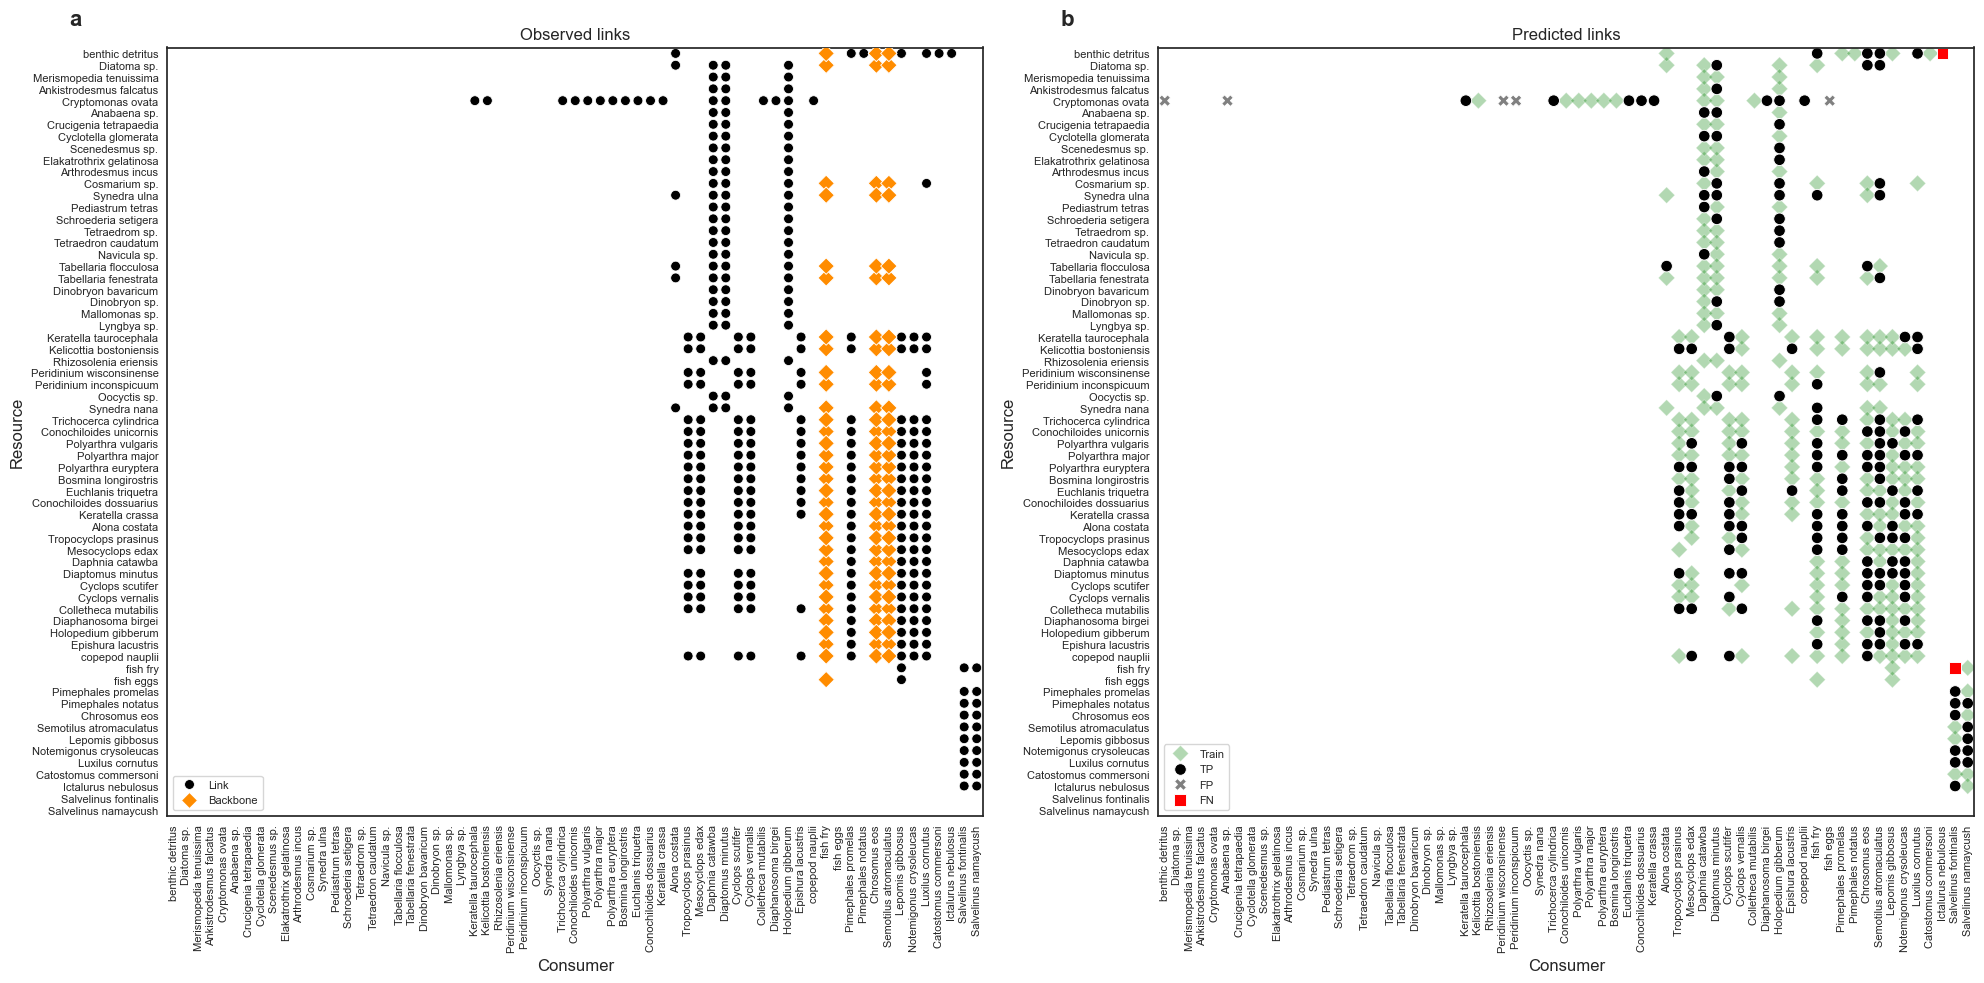

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.io
from scipy.sparse import coo_matrix, csr_matrix
import os

# Apply seaborn style
sns.set_theme(style="white", font_scale=1.0)

# =========================
# Figure controls (flags)
# =========================
MAX_PLOTS = 5

SHOW_TITLES = True
SHOW_TICKS = True

TITLE_LEFT = "Observed links"
TITLE_RIGHT = "Predicted links"

XLAB = "Consumer"
YLAB = "Resource"

# IMPORTANT: match your exported file suffix, e.g. "..._ratio60_..."
RATIO_PCT = 60
K_VAL = 10
NODE_SELECTION = "random"

# =========================
# NEW: optional single-foodweb mode
# =========================
# Set to None to run as before.
# Examples:
#   TARGET_FOODWEB = "ChesapeakeBay_tax_mass"  # exact match
#   TARGET_FOODWEB = "ChesapeakeBay"           # prefix before first "_"
TARGET_FOODWEB = "Long Lake"

# === Load foodweb names list ===
foodwebs_list_df = pd.read_csv("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

# === Base paths ===
base_csv_path = "../../../src/matlab/data/result_trainRatio_60_backboneRatio_50/confusion_matrix_csv"
base_mat_path = "../../../src/matlab/data/foodwebs_mat"

plots_done = 0

# =========================
# NEW: choose which foodwebs to iterate (leave loop logic intact)
# =========================
all_foodwebs = foodwebs_list_df["Foodweb"].astype(str).tolist()

if TARGET_FOODWEB is None:
    foodweb_iter = all_foodwebs
else:
    exact = [fw for fw in all_foodwebs if fw == TARGET_FOODWEB]
    if exact:
        foodweb_iter = exact
    else:
        prefix_matches = [fw for fw in all_foodwebs if fw.split("_")[0] == TARGET_FOODWEB]
        foodweb_iter = prefix_matches

    if not foodweb_iter:
        raise ValueError(
            f"TARGET_FOODWEB='{TARGET_FOODWEB}' not found in foodweb list. "
            f"Example valid values: {all_foodwebs[:5]}"
        )

# === Iterate over each foodweb ===
for foodweb in foodweb_iter:
    if plots_done >= MAX_PLOTS:
        break

    print(f"\nProcessing: {foodweb.split('_')[0]}")

    try:
        # === Load CSV prediction results ===
        tp_file = os.path.join(base_csv_path, f"{foodweb}_K_{K_VAL}_{NODE_SELECTION}_ratio{RATIO_PCT}_TP_links.csv")
        fp_file = os.path.join(base_csv_path, f"{foodweb}_K_{K_VAL}_{NODE_SELECTION}_ratio{RATIO_PCT}_FP_links.csv")
        fn_file = os.path.join(base_csv_path, f"{foodweb}_K_{K_VAL}_{NODE_SELECTION}_ratio{RATIO_PCT}_FN_links.csv")
        train_file = os.path.join(base_csv_path, f"{foodweb}_K_{K_VAL}_{NODE_SELECTION}_ratio{RATIO_PCT}_train_links.csv")

        # NEW: backbone links (same folder / naming as your examples)
        backbone_file = os.path.join(base_csv_path, f"{foodweb}_K_{K_VAL}_{NODE_SELECTION}_ratio{RATIO_PCT}_backbone_links.csv")

        mat_file = os.path.join(base_mat_path, f"{foodweb}.mat")

        tp = pd.read_csv(tp_file).dropna(subset=['Prey', 'Predator'])
        fp = pd.read_csv(fp_file).dropna(subset=['Prey', 'Predator'])
        fn = pd.read_csv(fn_file).dropna(subset=['Prey', 'Predator'])

        # === Load .mat adjacency and metadata ===
        mat_data = scipy.io.loadmat(mat_file)
        net = mat_data['net']
        taxonomy = [str(t[0]) if isinstance(t, (list, np.ndarray)) else str(t) for t in mat_data['taxonomy'].flatten()]
        mass = mat_data['mass'].flatten()

        # === Sort species by mass ===
        taxonomy_df = pd.DataFrame({'Species': taxonomy, 'Mass': mass})
        taxonomy_df = taxonomy_df.dropna().sort_values(by='Mass').reset_index(drop=True)
        sorted_species = taxonomy_df['Species'].tolist()
        species_index = {name: i for i, name in enumerate(sorted_species)}
        N = len(sorted_species)
        sorted_species_reversed = sorted_species[::-1]

        # === Sort adjacency matrix by mass ===
        if isinstance(net, coo_matrix):
            net = net.tocsr()
        elif isinstance(net, (np.ndarray, list)):
            net = csr_matrix(net)

        idx_sorted = [taxonomy.index(sp) for sp in sorted_species]
        adj_sorted = net[np.ix_(idx_sorted, idx_sorted)].toarray().astype(float)

        # === Build DataFrame for Adjacency Matrix (non-zero links) ===
        am_rows, am_cols = np.where(adj_sorted == 1)
        df_am = pd.DataFrame({
            'PreyIdx': N - 1 - am_rows,  # flip y-axis
            'PredIdx': am_cols,
            'Label': 'Link'
        })

        # NEW: Load Backbone Links (if available) and map into the SAME index system
        df_backbone = None
        if os.path.isfile(backbone_file):
            bb = pd.read_csv(backbone_file).dropna(subset=['Prey', 'Predator'])
            bb = bb[bb['Prey'].isin(species_index) & bb['Predator'].isin(species_index)]
            if not bb.empty:
                df_backbone = pd.DataFrame({
                    'PreyIdx': bb['Prey'].map(species_index),
                    'PredIdx': bb['Predator'].map(species_index),
                    'Label': 'Backbone'
                }).dropna().astype({'PreyIdx': int, 'PredIdx': int})
                df_backbone['PreyIdx'] = N - 1 - df_backbone['PreyIdx']

        # === Filter predictions to valid species ===
        tp = tp[tp['Prey'].isin(species_index) & tp['Predator'].isin(species_index)]
        fp = fp[fp['Prey'].isin(species_index) & fp['Predator'].isin(species_index)]
        fn = fn[fn['Prey'].isin(species_index) & fn['Predator'].isin(species_index)]

        # === Build DataFrame for Predation Matrix
        def make_df(df, label):
            return pd.DataFrame({
                'PreyIdx': df['Prey'].map(species_index),
                'PredIdx': df['Predator'].map(species_index),
                'Label': label
            })

        df_pm = pd.concat([
            make_df(tp, 'TP'),
            make_df(fp, 'FP'),
            make_df(fn, 'FN')
        ]).dropna().astype({'PreyIdx': int, 'PredIdx': int})
        df_pm['PreyIdx'] = N - 1 - df_pm['PreyIdx']

        # === Load Training Links (if available)
        df_train = None
        if os.path.isfile(train_file):
            train = pd.read_csv(train_file).dropna(subset=['Prey', 'Predator'])
            train = train[train['Prey'].isin(species_index) & train['Predator'].isin(species_index)]
            df_train = pd.DataFrame({
                'PreyIdx': train['Prey'].map(species_index),
                'PredIdx': train['Predator'].map(species_index),
                'Label': 'Train'
            })
            df_train['PreyIdx'] = N - 1 - df_train['PreyIdx']

        # === Plotting
        fig, axs = plt.subplots(1, 2, figsize=(20, 10))

        axs[0].text(-0.12, 1.05, "a", transform=axs[0].transAxes,
                    fontsize=16, fontweight="bold", va="top", ha="left", clip_on=False)
        axs[1].text(-0.12, 1.05, "b", transform=axs[1].transAxes,
                    fontsize=16, fontweight="bold", va="top", ha="left", clip_on=False)

        # LEFT: Observed links (adjacency)
        sns.scatterplot(
            data=df_am, x='PredIdx', y='PreyIdx', hue='Label', style='Label',
            markers={'Link': 'o'}, palette={'Link': 'black'}, s=50, ax=axs[0]
        )

        # overlay backbone as ORANGE DIAMONDS
        if df_backbone is not None:
            sns.scatterplot(
                data=df_backbone, x='PredIdx', y='PreyIdx', hue='Label', style='Label',
                markers={'Backbone': 'D'}, palette={'Backbone': 'darkorange'},
                s=70, ax=axs[0], zorder=3
            )

        # RIGHT: Predicted links
        ax = axs[1]

        if df_train is not None:
            sns.scatterplot(
                data=df_train, x='PredIdx', y='PreyIdx', hue='Label', style='Label',
                markers={'Train': 'D'}, palette={'Train': 'green'},
                alpha=0.3, s=70, legend='brief', ax=ax
            )

        sns.scatterplot(
            data=df_pm, x='PredIdx', y='PreyIdx', hue='Label', style='Label',
            markers={'TP': 'o', 'FP': 'X', 'FN': 's', 'Train': 'D'},
            palette={'TP': 'black', 'FP': 'gray', 'FN': 'red', 'Train': 'green'},
            s=70, ax=ax
        )

        ax.legend(loc='lower left', fontsize=8, title="")

        # =========================
        # Professional axes styling
        # =========================
        for a in axs:
            a.invert_yaxis()
            a.set_xlim(-0.5, N - 0.5)
            a.set_ylim(-0.5, N - 0.5)

            if SHOW_TITLES:
                a.set_title(TITLE_LEFT if a is axs[0] else TITLE_RIGHT, fontsize=12)
            else:
                a.set_title("")

            a.set_xlabel(XLAB)
            a.set_ylabel(YLAB)

            if SHOW_TICKS:
                a.set_xticks(range(N))
                a.set_yticks(range(N))
                a.set_xticklabels(sorted_species, rotation=90, fontsize=8)
                a.set_yticklabels(sorted_species_reversed, fontsize=8)
                a.tick_params(axis='both', which='both', length=3)
            else:
                a.set_xticks([])
                a.set_yticks([])
                a.set_xticklabels([])
                a.set_yticklabels([])
                a.tick_params(axis='both', which='both', length=0)

        # keep your current behaviour: legend on left is present
        axs[0].legend(loc='lower left', fontsize=8, title="")

        plt.tight_layout()
        plt.show()

        plots_done += 1

    except Exception as e:
        print(f"Skipping {foodweb} due to error: {e}")

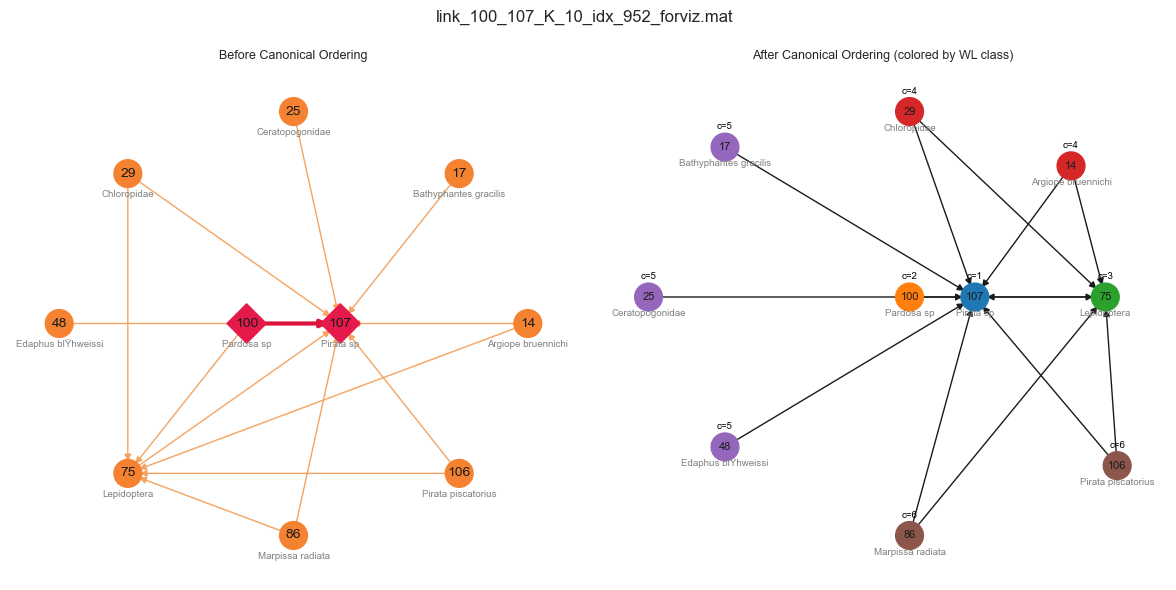

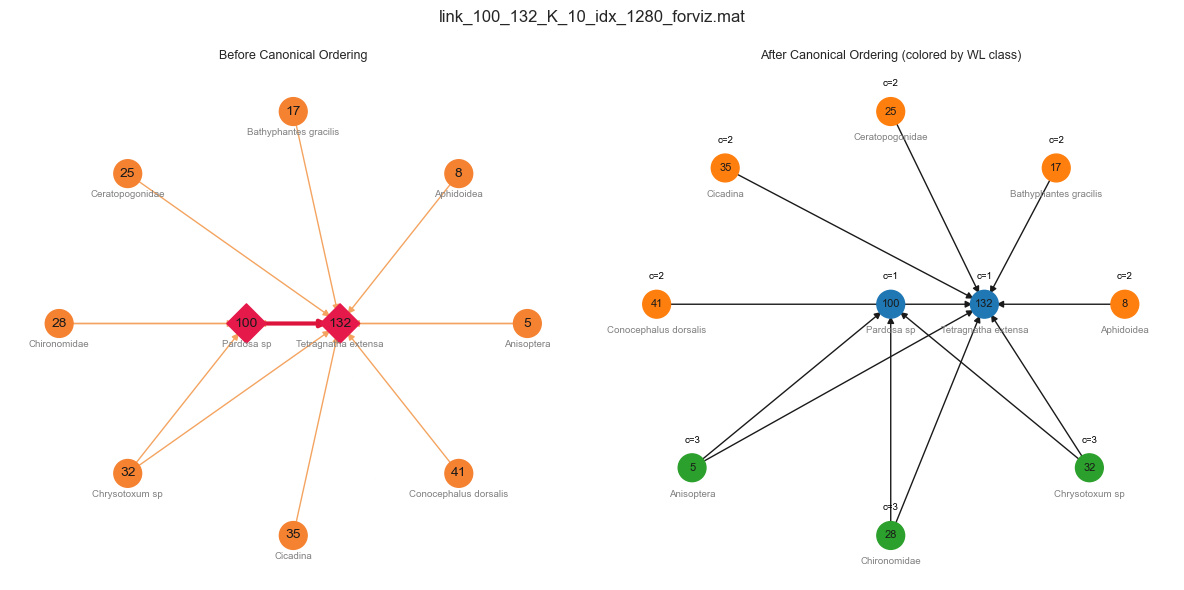

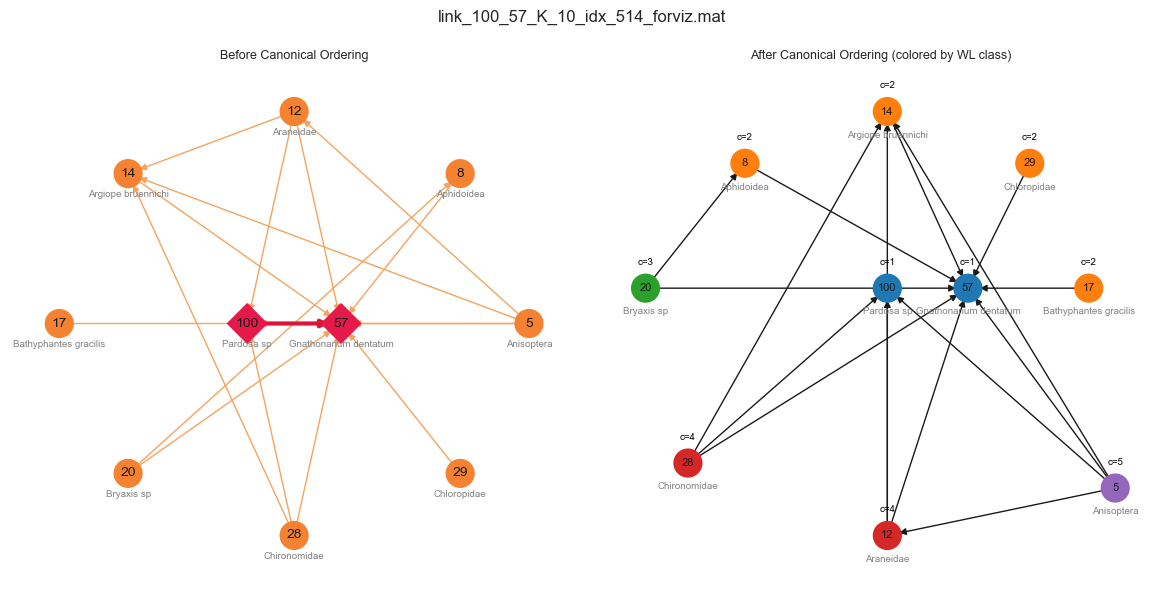

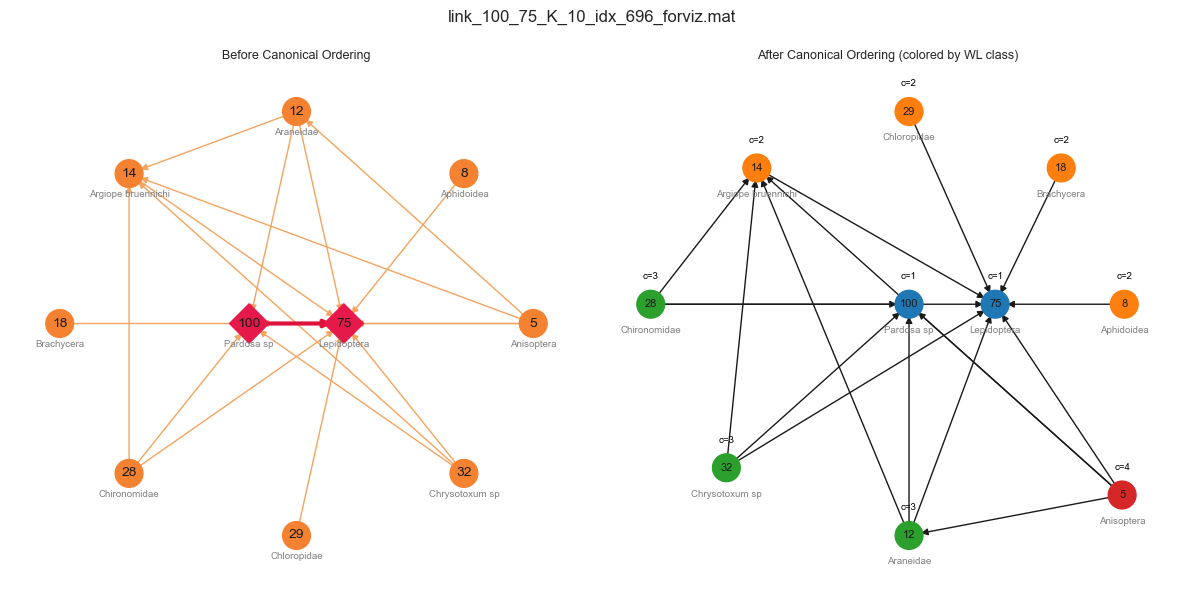

In [2]:
import os
import scipy.io
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import math

# Función de colores por clase WL
def get_node_colors_by_classes(classes):
    unique_classes = np.unique(classes)
    cmap = plt.get_cmap("tab10") if len(unique_classes) <= 10 else plt.get_cmap("tab20")
    color_map = {cls: cmap(i % cmap.N) for i, cls in enumerate(unique_classes)}
    return [color_map[c] for c in classes]

# Layout centrado para G1
def centered_layout(G, link, radius=2.5):
    source, target = link
    pos = {
        source: np.array([-0.5, 0.0]),
        target: np.array([0.5, 0.0])
    }
    remaining = [n for n in G.nodes() if n not in link]
    n = len(remaining)
    if n == 0:
        return pos
    angles = np.linspace(0, 2 * math.pi, n, endpoint=False)
    for i, node in enumerate(remaining):
        pos[node] = np.array([radius * math.cos(angles[i]), radius * math.sin(angles[i])])
    return pos

# Función principal de visualización
def visualize_subgraph_pair(mat_block_path, mat_full_path):
    mat_block = scipy.io.loadmat(mat_block_path)
    required_keys = ['adj_before', 'adj_after', 'nodes', 'nodes_ordered', 'classes', 'link', 'label']
    if not all(k in mat_block for k in required_keys):
        print(f"⚠️ Skipping incomplete: {os.path.basename(mat_block_path)}")
        return

    label = int(mat_block["label"].flatten()[0])
    if ONLY_POSITIVES and label == 0:
        return

    A_before = mat_block["adj_before"]
    A_after = mat_block["adj_after"]
    nodes = mat_block["nodes"].flatten()
    nodes_ordered = mat_block["nodes_ordered"].flatten()
    classes = mat_block["classes"].flatten()
    link = mat_block["link"].flatten()
    pred, prey = map(int, link)

    # Cargar metadata del food web completo
    if not os.path.exists(mat_full_path):
        print(f"⛔️ Foodweb file missing: {mat_full_path}")
        return
    mat_full = scipy.io.loadmat(mat_full_path)
    taxonomy_raw = mat_full.get("taxonomy")
    if taxonomy_raw is None:
        print(f"⛔️ 'taxonomy' missing in {mat_full_path}")
        return
    taxonomy = [str(t[0]) for t in taxonomy_raw[0]]

    G1 = nx.from_numpy_array(A_before, create_using=nx.DiGraph)
    G2 = nx.from_numpy_array(A_after, create_using=nx.DiGraph)
    mapping_before = {i: int(nodes[i]) for i in range(len(nodes))}
    mapping_after = {i: int(nodes_ordered[i]) for i in range(len(nodes_ordered))}
    G1 = nx.relabel_nodes(G1, mapping_before)
    G2 = nx.relabel_nodes(G2, mapping_after)

    # Omitir subgrafos donde el link no existe
    if not G1.has_edge(pred, prey):
        # print(f"⏭️  Skipping: link ({pred} → {prey}) not in G1 for {os.path.basename(mat_block_path)}")
        return

    highlighted_nodes = {pred, prey}
    node_colors_G1 = ['#e6194b' if n in highlighted_nodes else '#f58231' for n in G1.nodes()]
    node_shapes_G1 = ['D' if n in highlighted_nodes else 'o' for n in G1.nodes()]
    colors_G2 = get_node_colors_by_classes(classes)

    pos1 = centered_layout(G1, link)
    center_pred = (0.0, 0.0)
    center_prey = (1.0, 0.0)
    radius_base = 1.5
    pos2 = {pred: center_pred, prey: center_prey}
    rest_nodes = [n for i, n in enumerate(G2.nodes()) if n not in (pred, prey)]
    rest_classes = [classes[i] for i, n in enumerate(G2.nodes()) if n not in (pred, prey)]
    angle_step = 2 * math.pi / len(rest_nodes) if rest_nodes else 0

    for i, node in enumerate(rest_nodes):
        c = rest_classes[i]
        radius = radius_base + 0.5 * c
        angle = i * angle_step
        x = radius * math.cos(angle)
        y = radius * math.sin(angle)
        pos2[node] = (x, y)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    for shape in set(node_shapes_G1):
        nodelist = [n for n, s in zip(G1.nodes(), node_shapes_G1) if s == shape]
        colorlist = [node_colors_G1[list(G1.nodes()).index(n)] for n in nodelist]
        nx.draw_networkx_nodes(G1, pos1, nodelist=nodelist, node_color=colorlist,
                               node_shape=shape, node_size=400, ax=axs[0])

    normal_edges_G1 = [e for e in G1.edges() if e != (pred, prey)]
    nx.draw_networkx_edges(G1, pos1, edgelist=normal_edges_G1, edge_color='sandybrown', arrows=True, ax=axs[0])
    if G1.has_edge(pred, prey):
        nx.draw_networkx_edges(G1, pos1, edgelist=[(pred, prey)], edge_color='crimson', width=3, arrows=True, ax=axs[0])

    nx.draw_networkx_labels(G1, pos1, ax=axs[0], font_size=10)
    for node in G1.nodes():
        x, y = pos1[node]
        name = taxonomy[node] if 0 <= node < len(taxonomy) else str(node)
        axs[0].text(x, y - 0.3, name, fontsize=7, ha='center', va='bottom', color='grey')

    axs[0].set_title("Before Canonical Ordering", fontsize=9)
    axs[0].axis("off")

    nx.draw_networkx_nodes(G2, pos2, ax=axs[1], node_color=colors_G2, node_size=400)
    nx.draw_networkx_edges(G2, pos2, ax=axs[1], arrows=True)
    nx.draw_networkx_labels(G2, pos2, ax=axs[1], font_size=8)
    for i, node in enumerate(G2.nodes()):
        x, y = pos2[node]
        name = taxonomy[node] if 0 <= node < len(taxonomy) else str(node)
        axs[1].text(x, y + 0.3, f"c={classes[i]}", fontsize=7, ha='center', va='bottom', color='black')
        axs[1].text(x, y - 0.4, name, fontsize=7, ha='center', va='bottom', color='grey')

    axs[1].set_title("After Canonical Ordering (colored by WL class)", fontsize=9)
    axs[1].axis("off")
    fig.suptitle(os.path.basename(mat_block_path), fontsize=12)
    plt.tight_layout()
    plt.show()

# Configuración
ONLY_POSITIVES = True
LIMIT = 5  # Limitar la cantidad de visualizaciones
foodweb_name = "Grand Caricaie  marsh dominated by Cladietum marisci, mown  Clmown1_tax_mass"
building_blocks_dir = f"../../../src/matlab/data/result_building_blocks/building_blocks/{foodweb_name}"
mat_full_path = f"../../../src/matlab/data/foodwebs_mat/{foodweb_name}.mat"

# Ejecutar visualización para archivos limitados
mat_files = sorted([os.path.join(building_blocks_dir, f) for f in os.listdir(building_blocks_dir) if f.endswith(".mat")])[:LIMIT]
for path in mat_files:
    visualize_subgraph_pair(path, mat_full_path)

Found 290 CSV files matching pattern in ../../../src/matlab/data/result_kfold_cross-validation/prediction_scores_logs


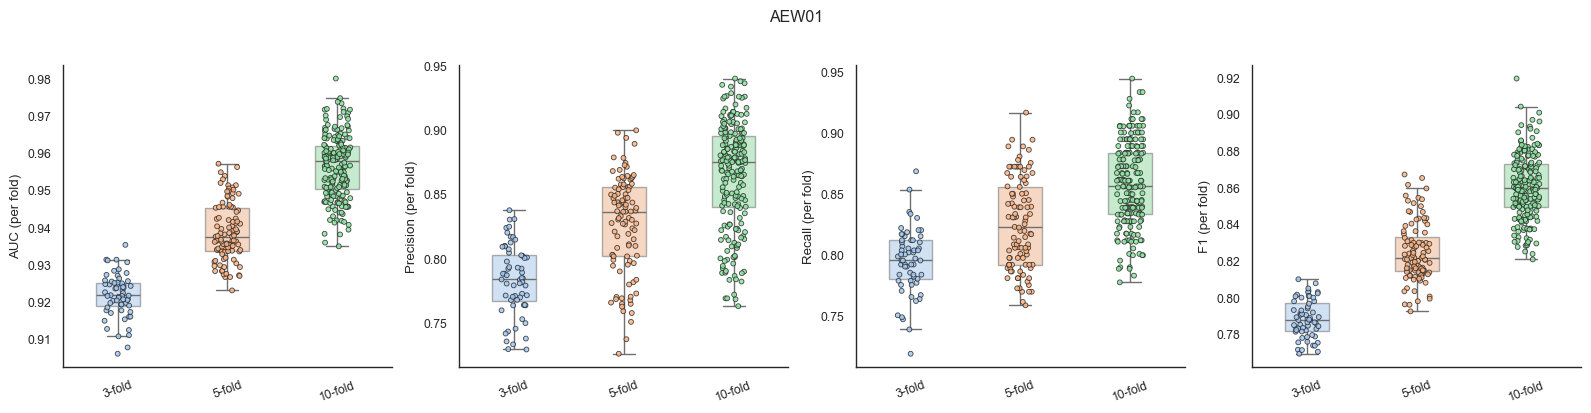

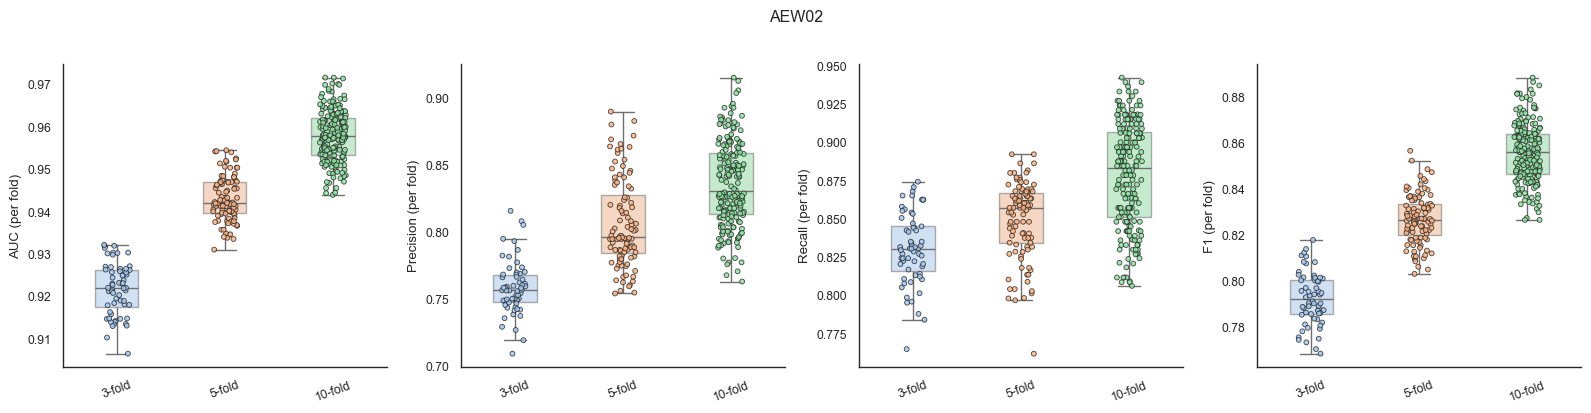

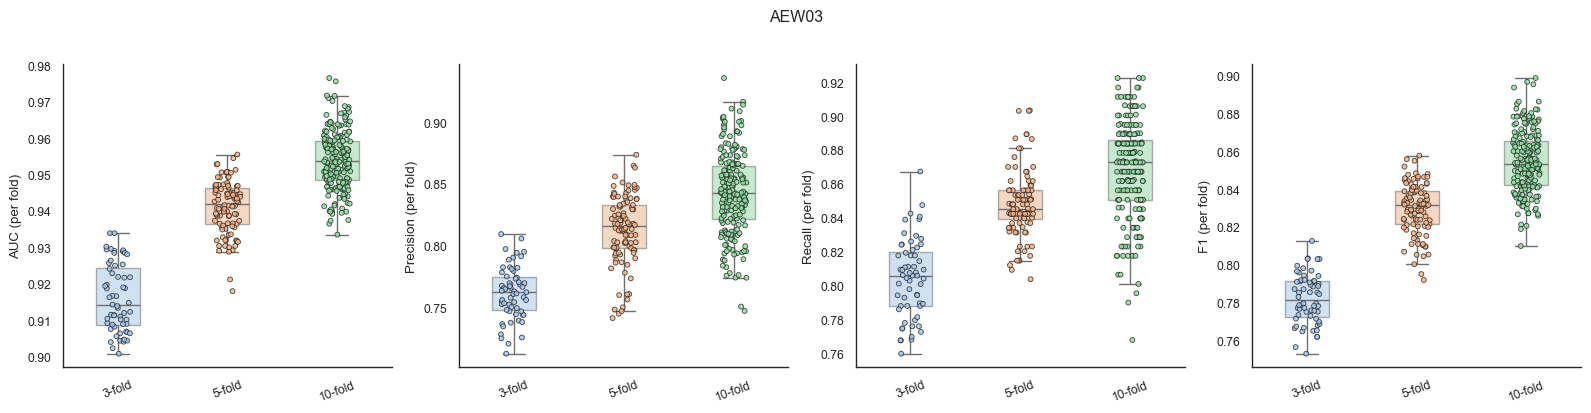

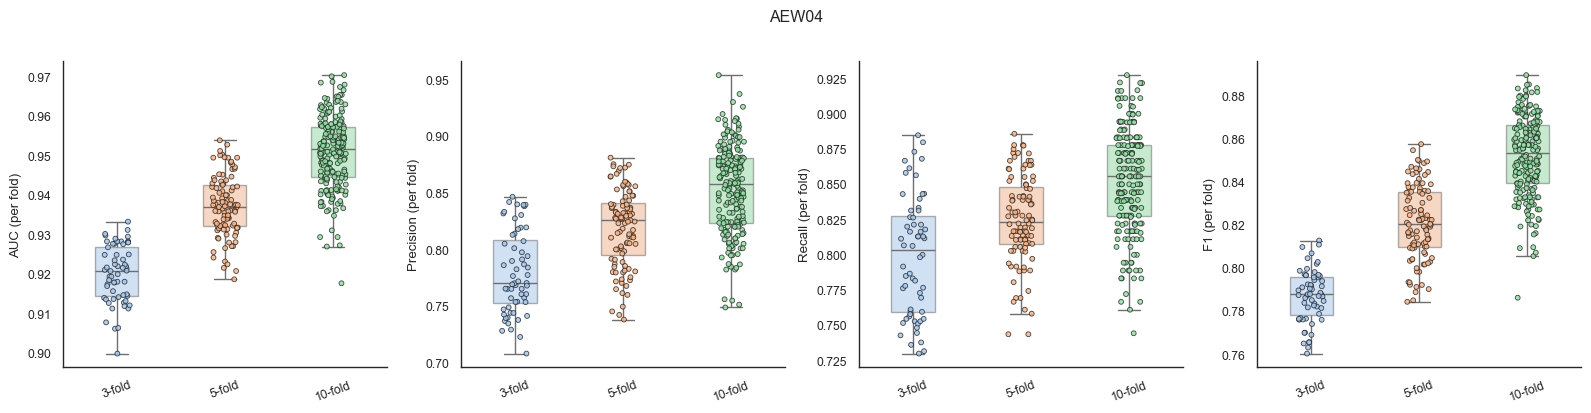

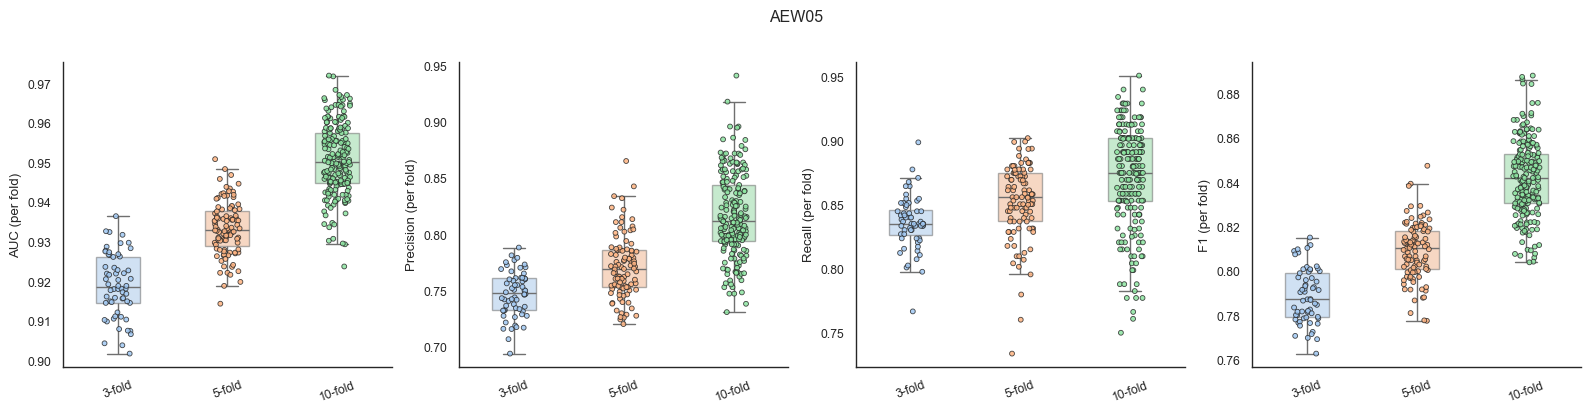

Done. Plotted 5 figures (limit=5).


In [3]:
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
LOG_DIR = "../../../src/matlab/data/result_kfold_cross-validation/prediction_scores_logs"
PATTERN = "*tax_mass_results_random_wlnm_dir_neg_kfold.csv"

K_TARGET = 10
cvk_order = [3, 5, 10]

sns.set_theme(context="paper", style="white")

# -----------------------------
# Helpers
# -----------------------------
def cvk_label(k: int) -> str:
    return f"{k}-fold"

def plot_one_foodweb(csv_path: str) -> bool:
    df = pd.read_csv(csv_path)

    metrics = ["AUC", "Precision", "Recall", "F1Score"]
    required_cols = {"CvK", *metrics}
    missing = required_cols - set(df.columns)
    if missing:
        print(f"[SKIP] {os.path.basename(csv_path)} missing columns: {sorted(missing)}")
        return False

    # Filter by K if present
    if "K" in df.columns:
        df = df[df["K"] == K_TARGET].copy()

    # Keep only desired CV regimes
    df = df[df["CvK"].isin(cvk_order)].copy()
    if df.empty:
        print(f"[SKIP] {os.path.basename(csv_path)} no rows after K/CvK filtering.")
        return False

    df["CvK"] = df["CvK"].astype(int)

    cvk_to_label = {k: cvk_label(k) for k in cvk_order}
    df["CvK_label"] = df["CvK"].map(cvk_to_label)

    present_cvks = [k for k in cvk_order if k in df["CvK"].unique()]
    present_labels = [cvk_to_label[k] for k in present_cvks]
    if len(present_labels) < 2:
        print(f"[SKIP] {os.path.basename(csv_path)} not enough CV regimes present.")
        return False

    # Palette (consistent across all 4 panels)
    palette = dict(zip(
        present_labels,
        sns.color_palette("pastel", n_colors=len(present_labels))
    ))

    # 1x4 layout
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=False, sharey=False)

    ylabels = {
        "AUC": "AUC (per fold)",
        "Precision": "Precision (per fold)",
        "Recall": "Recall (per fold)",
        "F1Score": "F1 (per fold)",
    }

    for ax, m in zip(axes, metrics):
        sns.boxplot(
            data=df,                 # <-- fold-level
            x="CvK_label",
            y=m,
            order=present_labels,
            showfliers=False,
            palette=palette,
            hue="CvK_label",
            legend=False,
            linewidth=1,
            width=0.4,
            ax=ax,
        )

        # semi-transparent boxes
        for patch in ax.patches:
            try:
                patch.set_alpha(0.55)
            except Exception:
                pass

        sns.stripplot(
            data=df,                 # <-- fold-level
            x="CvK_label",
            y=m,
            order=present_labels,
            jitter=0.12,
            size=3.5,
            alpha=0.85,
            palette=palette,
            hue="CvK_label",
            legend=False,
            edgecolor="0.15",
            linewidth=0.6,
            ax=ax,
        )

        ax.set_xlabel("")
        ax.set_ylabel(ylabels[m])
        ax.tick_params(axis="x", rotation=20)
        sns.despine(ax=ax)

    fw_name = os.path.basename(csv_path).replace(
        "_tax_mass_results_random_wlnm_dir_neg_kfold.csv", ""
    )
    fig.suptitle(fw_name, y=1.02)
    plt.tight_layout()
    plt.show()

    return True

# -----------------------------
# Main loop over all foodweb CSVs (limit to 5 plots)
# -----------------------------
csv_files = sorted(glob.glob(os.path.join(LOG_DIR, PATTERN)))
print(f"Found {len(csv_files)} CSV files matching pattern in {LOG_DIR}")

plotted = 0
MAX_PLOTS =5
for csv_path in csv_files:
    if plotted >= MAX_PLOTS:
        break
    did_plot = plot_one_foodweb(csv_path)
    if did_plot:
        plotted += 1

print(f"Done. Plotted {plotted} figures (limit={MAX_PLOTS}).")


Found 290 CSV files matching pattern in ../../../src/matlab/data/result_kfold_cross-validation/prediction_scores_logs

Foodweb count per CvK:
CvK
3     290
5     290
10    290
Name: Foodweb, dtype: int64


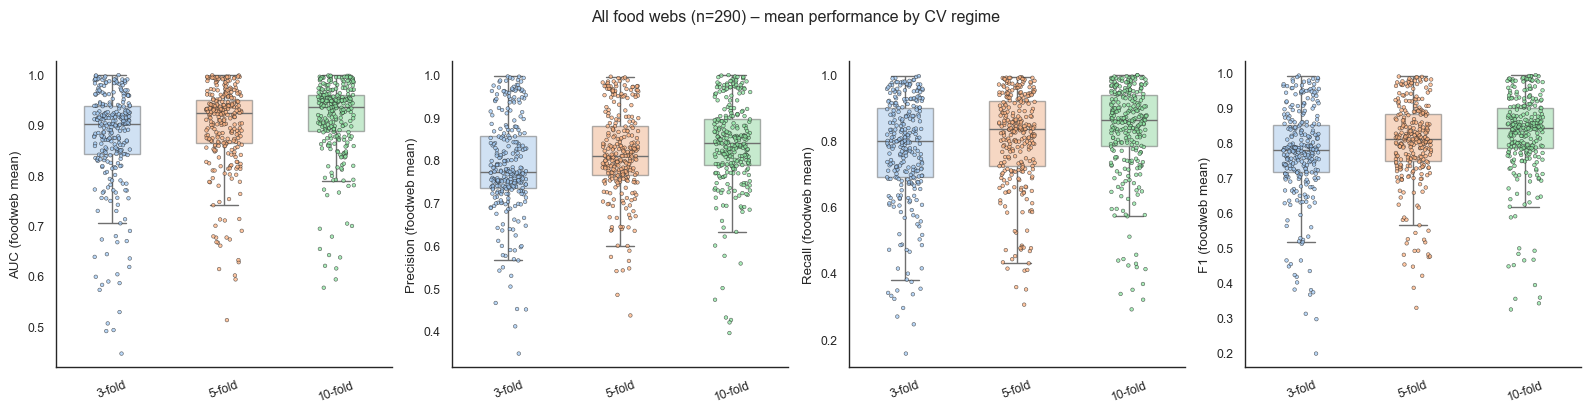

In [ ]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
LOG_DIR = "../../../src/matlab/data/result_kfold_cross-validation/prediction_scores_logs"
PATTERN = "*tax_mass_results_random_wlnm_dir_neg_kfold.csv"

K_TARGET = 10
cvk_order = [3, 5, 10]

sns.set_theme(context="paper", style="white")

# -----------------------------
# Helpers
# -----------------------------
def cvk_label(k: int) -> str:
    return f"{k}-fold"

def foodweb_name_from_path(p: str) -> str:
    return os.path.basename(p).replace("_tax_mass_results_random_wlnm_dir_neg_kfold.csv", "")

def collect_foodweb_means(log_dir: str, pattern: str) -> pd.DataFrame:
    metrics = ["AUC", "Precision", "Recall", "F1Score"]
    required_cols = {"CvK", *metrics}

    rows = []
    csv_files = sorted(glob.glob(os.path.join(log_dir, pattern)))
    print(f"Found {len(csv_files)} CSV files matching pattern in {log_dir}")

    for csv_path in csv_files:
        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"[SKIP] {os.path.basename(csv_path)} read error: {e}")
            continue

        missing = required_cols - set(df.columns)
        if missing:
            print(f"[SKIP] {os.path.basename(csv_path)} missing columns: {sorted(missing)}")
            continue

        # Filter by K if present
        if "K" in df.columns:
            df = df[df["K"] == K_TARGET].copy()

        # Keep only desired CV regimes
        df = df[df["CvK"].isin(cvk_order)].copy()
        if df.empty:
            print(f"[SKIP] {os.path.basename(csv_path)} no rows after K/CvK filtering.")
            continue

        df["CvK"] = df["CvK"].astype(int)

        # Mean across ALL fold-level rows for each CvK (per food web)
        agg = (
            df.groupby("CvK", as_index=False)[metrics]
              .mean()
        )

        fw = foodweb_name_from_path(csv_path)
        agg["Foodweb"] = fw

        rows.append(agg)

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)

    cvk_to_label = {k: cvk_label(k) for k in cvk_order}
    out["CvK_label"] = out["CvK"].map(cvk_to_label)

    return out

def plot_foodweb_means_1x4(df_means: pd.DataFrame) -> None:
    metrics = ["AUC", "Precision", "Recall", "F1Score"]
    if df_means.empty:
        print("No data to plot.")
        return

    # Keep only regimes present (and keep your intended order)
    present_cvks = [k for k in cvk_order if k in df_means["CvK"].unique()]
    present_labels = [cvk_label(k) for k in present_cvks]
    if len(present_labels) < 2:
        print("Not enough CV regimes present in aggregated data to plot.")
        return

    palette = dict(zip(
        present_labels,
        sns.color_palette("pastel", n_colors=len(present_labels))
    ))

    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=False, sharey=False)

    ylabels = {
        "AUC": "AUC (foodweb mean)",
        "Precision": "Precision (foodweb mean)",
        "Recall": "Recall (foodweb mean)",
        "F1Score": "F1 (foodweb mean)",
    }

    for ax, m in zip(axes, metrics):
        sns.boxplot(
            data=df_means,
            x="CvK_label",
            y=m,
            order=present_labels,
            showfliers=False,
            palette=palette,
            hue="CvK_label",
            legend=False,
            linewidth=1,
            width=0.5,
            ax=ax,
        )

        # semi-transparent boxes
        for patch in ax.patches:
            try:
                patch.set_alpha(0.55)
            except Exception:
                pass

        sns.stripplot(
            data=df_means,
            x="CvK_label",
            y=m,
            order=present_labels,
            jitter=0.16,      # a bit more jitter helps with ~290 points
            size=2.6,         # smaller dots for many food webs
            alpha=0.75,
            palette=palette,
            hue="CvK_label",
            legend=False,
            edgecolor="0.15",
            linewidth=0.4,
            ax=ax,
        )

        ax.set_xlabel("")
        ax.set_ylabel(ylabels[m])
        ax.tick_params(axis="x", rotation=20)
        sns.despine(ax=ax)

    n_fw = df_means["Foodweb"].nunique()
    fig.suptitle(f"All food webs (n={n_fw}) – mean performance by CV regime", y=1.02)
    plt.tight_layout()
    plt.show()

# -----------------------------
# Run
# -----------------------------
df_means = collect_foodweb_means(LOG_DIR, PATTERN)

# Optional sanity check: how many food webs per CvK made it in
print("\nFoodweb count per CvK:")
print(df_means.groupby("CvK")["Foodweb"].nunique())

plot_foodweb_means_1x4(df_means)

Found 290 CSV files matching pattern in ../../../src/matlab/data/result_kfold_cross-validation/prediction_scores_logs

Foodweb count per CvK:
CvK
3     290
5     290
10    290
Name: Foodweb, dtype: int64


/var/folders/37/n26ttb4n16xb2c3z17l2p6r00000gp/T/ipykernel_88147/3508273955.py:151: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order_labels, rotation=0)
/var/folders/37/n26ttb4n16xb2c3z17l2p6r00000gp/T/ipykernel_88147/3508273955.py:151: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order_labels, rotation=0)
/var/folders/37/n26ttb4n16xb2c3z17l2p6r00000gp/T/ipykernel_88147/3508273955.py:151: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order_labels, rotation=0)
/var/folders/37/n26ttb4n16xb2c3z17l2p6r00000gp/T/ipykernel_88147/3508273955.py:151: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xt

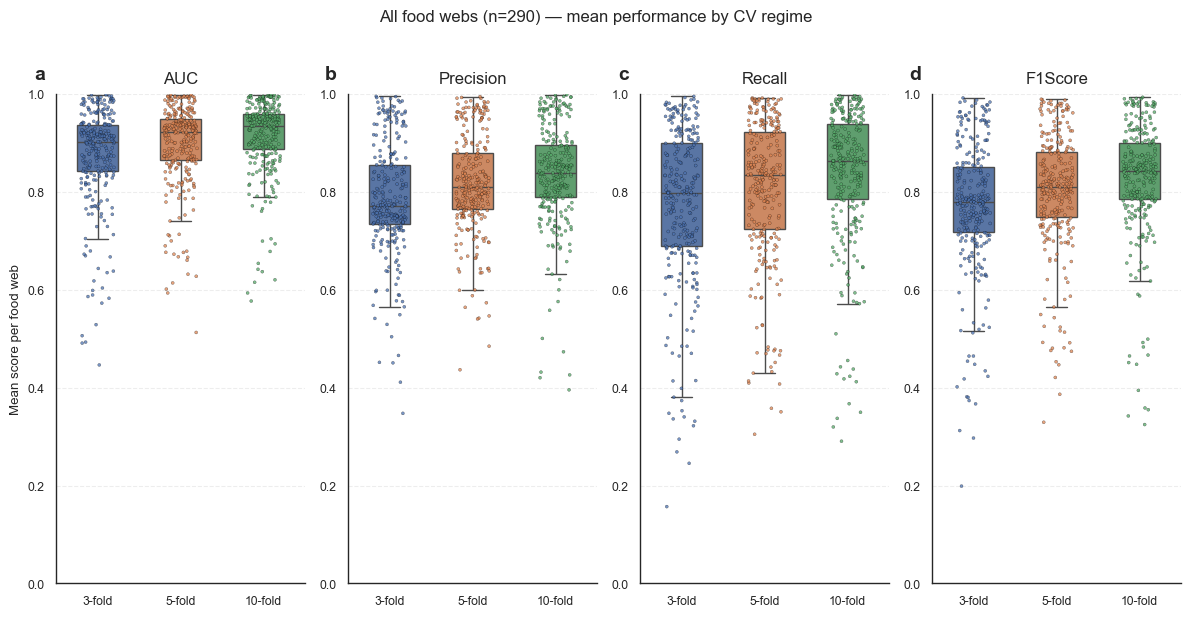

In [31]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Style (match old snippet)
# =========================
sns.set_context("paper")
sns.set_style("white")

# -----------------------------
# Config
# -----------------------------
LOG_DIR = "../../../src/matlab/data/result_kfold_cross-validation/prediction_scores_logs"
PATTERN = "*tax_mass_results_random_wlnm_dir_neg_kfold.csv"

K_TARGET = 10
cvk_order = [3, 5, 10]
METRICS = ["AUC", "Precision", "Recall", "F1Score"]

# -----------------------------
# Helpers
# -----------------------------
def cvk_label(k: int) -> str:
    return f"{k}-fold"

def foodweb_name_from_path(p: str) -> str:
    return os.path.basename(p).replace("_tax_mass_results_random_wlnm_dir_neg_kfold.csv", "")

def collect_foodweb_means(log_dir: str, pattern: str) -> pd.DataFrame:
    required_cols = {"CvK", *METRICS}

    rows = []
    csv_files = sorted(glob.glob(os.path.join(log_dir, pattern)))
    print(f"Found {len(csv_files)} CSV files matching pattern in {log_dir}")

    for csv_path in csv_files:
        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"[SKIP] {os.path.basename(csv_path)} read error: {e}")
            continue

        missing = required_cols - set(df.columns)
        if missing:
            print(f"[SKIP] {os.path.basename(csv_path)} missing columns: {sorted(missing)}")
            continue

        # Filter by K if present
        if "K" in df.columns:
            df = df[df["K"] == K_TARGET].copy()

        # Keep only desired CV regimes
        df = df[df["CvK"].isin(cvk_order)].copy()
        if df.empty:
            print(f"[SKIP] {os.path.basename(csv_path)} no rows after K/CvK filtering.")
            continue

        df["CvK"] = pd.to_numeric(df["CvK"], errors="coerce").astype("Int64")

        # Mean across ALL fold-level rows for each CvK (per food web)
        agg = (
            df.groupby("CvK", as_index=False)[METRICS]
              .mean()
        )

        fw = foodweb_name_from_path(csv_path)
        agg["Foodweb"] = fw

        rows.append(agg)

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)

    cvk_to_label = {k: cvk_label(k) for k in cvk_order}
    out["CvK_label"] = out["CvK"].map(cvk_to_label)

    return out

def plot_foodweb_means_1x4(df_means: pd.DataFrame) -> None:
    if df_means.empty:
        print("No data to plot.")
        return

    present_cvks = [k for k in cvk_order if k in df_means["CvK"].dropna().unique()]
    order_labels = [cvk_label(k) for k in present_cvks]
    if len(order_labels) < 2:
        print("Not enough CV regimes present to plot.")
        return

    # Palette (consistent across panels)
    pal = dict(zip(order_labels, sns.color_palette("deep", n_colors=len(order_labels))))

    fig, axes = plt.subplots(1, 4, figsize=(12, 6), sharex=False, sharey=False)
    letters = ["a", "b", "c", "d"]

    for idx, (ax, metric) in enumerate(zip(axes, METRICS)):
        # Boxplot
        sns.boxplot(
            data=df_means,
            x="CvK_label",
            y=metric,
            order=order_labels,
            palette=[pal[o] for o in order_labels],
            hue="CvK_label",
            width=0.5,
            showfliers=False,
            linewidth=1,
            ax=ax,
        )

        # Stripplot (points)
        sns.stripplot(
            data=df_means,
            x="CvK_label",
            y=metric,
            order=order_labels,
            palette=[pal[o] for o in order_labels],
            hue="CvK_label",
            dodge=False,
            jitter=0.20,
            s=2.2,            # <-- fixed dot size (matplotlib)
            alpha=0.75,
            edgecolor="black",
            linewidth=0.2,
            ax=ax,
        )

        # Remove per-axis legends (we keep none, like your old snippet)
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        ax.set_xlabel("")
        ax.set_title(metric, fontsize=12, pad=8)
        ax.set_ylim(0, 1.0)
        ax.yaxis.set_major_locator(plt.MaxNLocator(6))
        ax.grid(True, axis="y", linestyle="--", alpha=0.35)
        sns.despine(ax=ax)

        # Only left-most ylabel (match style)
        if metric == "AUC":
            ax.set_ylabel("Mean score per food web")
        else:
            ax.set_ylabel("")

        ax.set_xticklabels(order_labels, rotation=0)

        # Panel letter (top-left, outside)
        ax.annotate(
            letters[idx],
            xy=(0, 1), xycoords="axes fraction",
            xytext=(-8, 8), textcoords="offset points",
            ha="right", va="bottom",
            fontsize=14, fontweight="bold",
            annotation_clip=False,
        )

    n_fw = df_means["Foodweb"].nunique()
    fig.suptitle(f"All food webs (n={n_fw}) — mean performance by CV regime", y=1.02, fontsize=12)

    plt.tight_layout()
    plt.show()

# -----------------------------
# Run
# -----------------------------
df_means = collect_foodweb_means(LOG_DIR, PATTERN)

print("\nFoodweb count per CvK:")
print(df_means.groupby("CvK")["Foodweb"].nunique())

plot_foodweb_means_1x4(df_means)


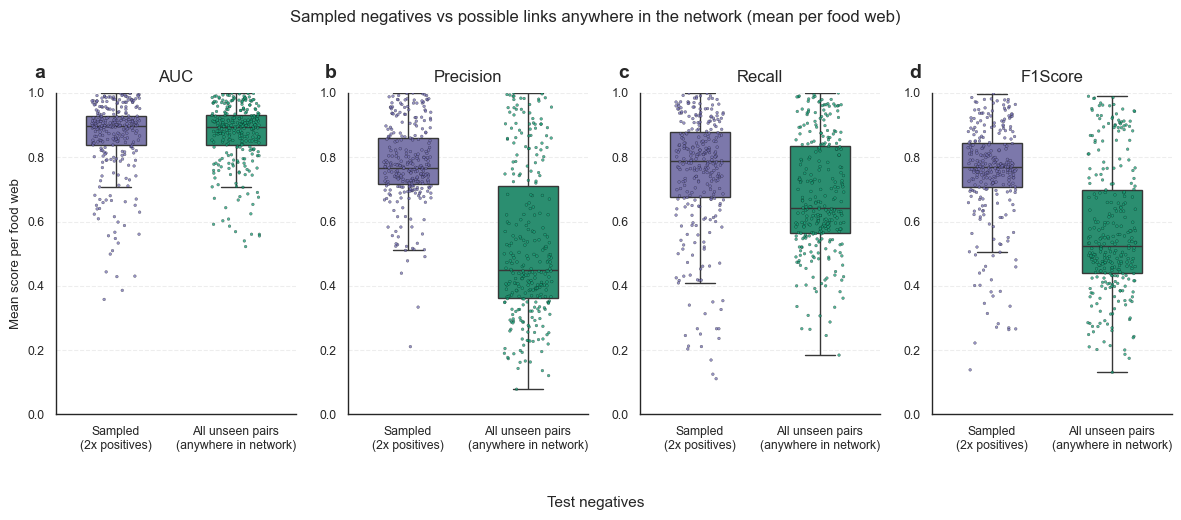

In [8]:
import os
import re
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# =========================
# Style (match old snippet)
# =========================
sns.set_theme(context="paper", style="white", font_scale=1.0)


# =========================
# Config
# =========================
RESULTS_DIR_SAMPLED = Path("../../../src/matlab/data/result_evaluate_on_all_unseen-false/prediction_scores_logs")
RESULTS_DIR_ALL_UNSEEN = Path("../../../src/matlab/data/result_evaluate_on_all_unseen-true/prediction_scores_logs")

METRICS = ["AUC", "Precision", "Recall", "F1Score"]

K_TARGET = None
K_COL = "K"

GLOB_PATTERN = "*_tax_mass_results_random_wlnm_dir_neg.csv"


# =========================
# Helpers
# =========================
def parse_regime_from_name(fname: str) -> str:
    m = re.search(r"evaluate_on_all_unseen-(true|false)", fname.lower())
    if not m:
        return "unknown"
    return "all_unseen" if m.group(1) == "true" else "sampled"


def parse_foodweb_from_name(fname: str) -> str:
    base = Path(fname).name
    if "_results_" in base:
        return base.split("_results_")[0]
    return Path(fname).stem


def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def load_one_csv(csv_path: Path, regime_hint: str | None = None) -> dict | None:
    df = pd.read_csv(csv_path)

    present_metrics = [m for m in METRICS if m in df.columns]
    if not present_metrics:
        print(f"[SKIP] Missing all metrics {METRICS}: {csv_path.name}")
        return None

    df = coerce_numeric(df, present_metrics + [K_COL])

    if K_TARGET is not None and K_COL in df.columns:
        df = df[df[K_COL] == K_TARGET].copy()
        if df.empty:
            return None

    regime = parse_regime_from_name(csv_path.name)
    if regime == "unknown" and regime_hint in {"sampled", "all_unseen"}:
        regime = regime_hint

    out = {
        "Foodweb": parse_foodweb_from_name(csv_path.name),
        "Regime": regime,
        "n_rows": int(len(df)),
        "file": csv_path.name,
        "folder": str(csv_path.parent),
    }

    for m in METRICS:
        if m in df.columns:
            vals = df[m].dropna().values
            out[f"{m}_mean"] = float(np.mean(vals)) if vals.size else np.nan
        else:
            out[f"{m}_mean"] = np.nan

    if np.isnan(out["AUC_mean"]):
        return None

    return out


def load_folder(folder: Path, regime_hint: str) -> list[dict]:
    csv_files = sorted(folder.glob(GLOB_PATTERN))
    if not csv_files:
        raise FileNotFoundError(
            f"No files found in {folder.resolve()} matching: {GLOB_PATTERN}"
        )

    rows = []
    for p in csv_files:
        rec = load_one_csv(p, regime_hint=regime_hint)
        if rec is not None and rec["Regime"] in {"sampled", "all_unseen"}:
            rows.append(rec)
    return rows


# =========================
# Load all CSVs (two folders)
# =========================
rows = []
rows += load_folder(RESULTS_DIR_SAMPLED, regime_hint="sampled")
rows += load_folder(RESULTS_DIR_ALL_UNSEEN, regime_hint="all_unseen")

df_all = pd.DataFrame(rows)

if df_all.empty:
    raise RuntimeError("No valid rows after loading both folders. Check patterns or CSV columns.")


# =========================
# Optional: enforce one row per (Foodweb, Regime)
# =========================
mean_cols = [f"{m}_mean" for m in METRICS]
df_all = (
    df_all
    .groupby(["Foodweb", "Regime"], as_index=False)[mean_cols]
    .mean()
)

# =========================
# Plot: 1x4 boxplots + points (style intact)
# =========================
order = ["sampled", "all_unseen"]

# Short per-regime labels (for the tick labels)
label_map_short = {
    "sampled": "Sampled\n(2x positives)",
    "all_unseen": "All unseen pairs\n(anywhere in network)",
}

palette = {
    "sampled": "#1b9e77",
    "all_unseen": "#7570b3",
}

fig, axes = plt.subplots(1, 4, figsize=(12, 5))
letters = ["a", "b", "c", "d"]

for idx, (ax, metric) in enumerate(zip(axes, METRICS)):
    ycol = f"{metric}_mean"

    sns.boxplot(
        data=df_all,
        x="Regime",
        y=ycol,
        order=order,
        palette=[palette[o] for o in order],
        hue="Regime",
        width=0.5,
        showfliers=False,
        ax=ax,
    )

    sns.stripplot(
        data=df_all,
        x="Regime",
        y=ycol,
        order=order,
        palette=[palette[o] for o in order],
        hue="Regime",
        dodge=False,
        jitter=0.20,
        size=2.0,
        alpha=0.75,
        edgecolor="black",
        linewidth=0.2,
        ax=ax,
    )

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # --- x-axis: show only the short subtitles on ticks ---
    ax.set_xlabel("")
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([label_map_short[o] for o in order], rotation=0)

    if metric == "AUC":
        ax.set_ylabel("Mean score per food web")
    else:
        ax.set_ylabel("")

    ax.set_title(metric, fontsize=12, pad=8)
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_locator(plt.MaxNLocator(6))
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    sns.despine(ax=ax)

    # ---- panel letter (top-left) ----
    ax.annotate(
        letters[idx],
        xy=(0, 1), xycoords="axes fraction",
        xytext=(-8, 8), textcoords="offset points",
        ha="right", va="bottom",
        fontsize=14, fontweight="bold",
        annotation_clip=False,
    )

# --- ONE shared x-axis title for the full figure ---
fig.supxlabel("Test negatives", y=0.02, fontsize=11)

fig.suptitle(
    "Sampled negatives vs possible links anywhere in the network (mean per food web)",
    y=1.02,
    fontsize=12,
)

# Leave your layout logic intact; just add a small bottom margin for the shared x-label
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


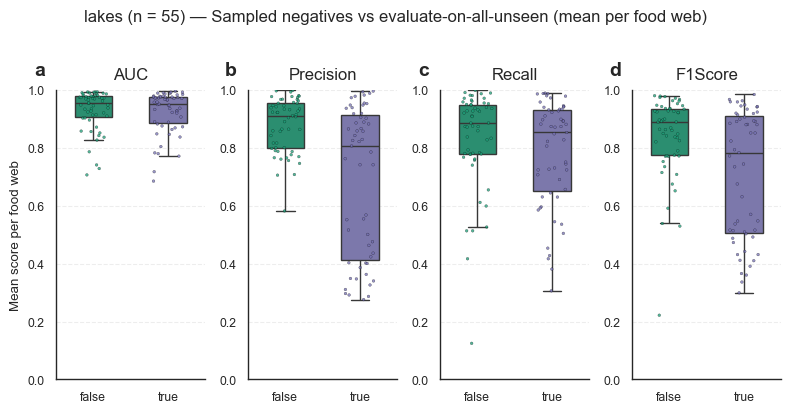

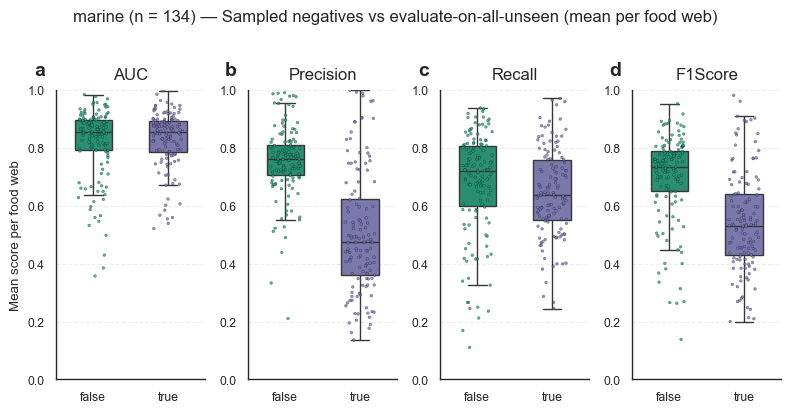

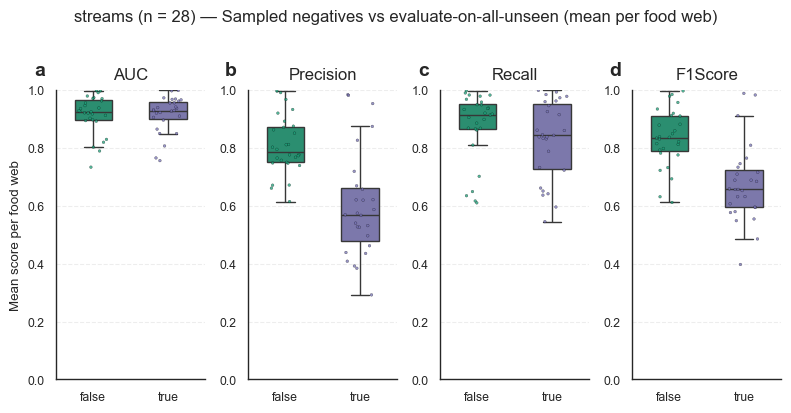

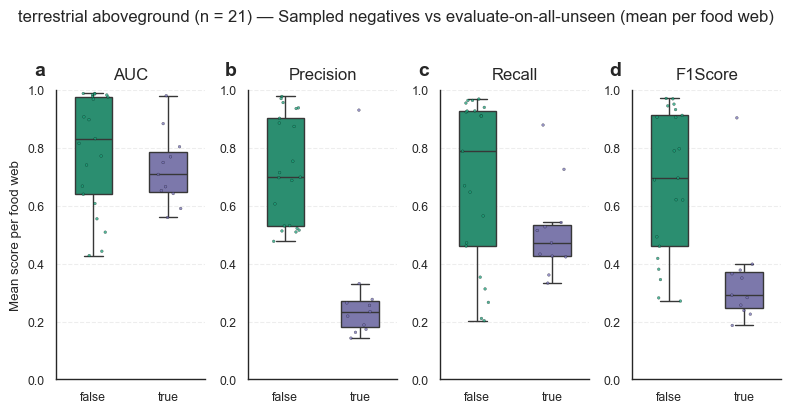

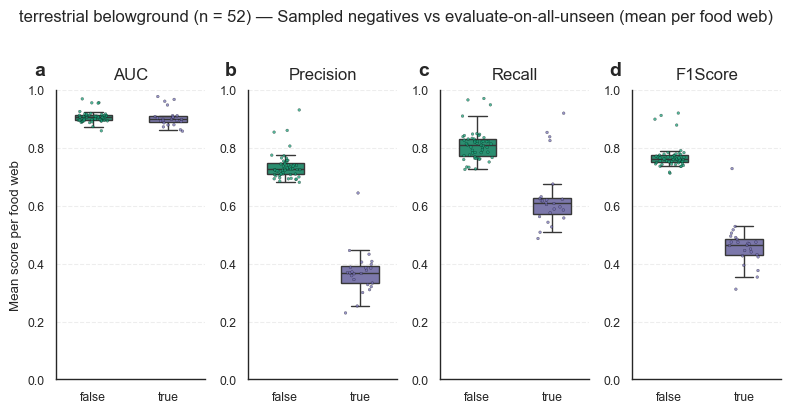

In [ ]:
import os
import re
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# =========================
# Style (match old snippet)
# =========================
sns.set_context("paper")
sns.set_style("white")


# =========================
# Config
# =========================
RESULTS_DIR_SAMPLED = Path("../../../src/matlab/data/result_evaluate_on_all_unseen-false/prediction_scores_logs")
RESULTS_DIR_ALL_UNSEEN = Path("../../../src/matlab/data/result/prediction_scores_logs")

# Ecosystem metadata
ECOSYSTEM_FILE = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

METRICS = ["AUC", "Precision", "Recall", "F1Score"]

K_TARGET = None
K_COL = "K"

GLOB_PATTERN = "*_tax_mass_results_random_wlnm_dir_neg.csv"


# =========================
# Helpers
# =========================
def parse_regime_from_name(fname: str) -> str:
    m = re.search(r"evaluate_on_all_unseen-(true|false)", fname.lower())
    if not m:
        return "unknown"
    return "all_unseen" if m.group(1) == "true" else "sampled"


def parse_foodweb_from_name(fname: str) -> str:
    base = Path(fname).name
    if "_results_" in base:
        return base.split("_results_")[0]
    return Path(fname).stem


def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def normalize_fw_label(name: str) -> str:
    """
    Normalize foodweb labels so results filenames and ecosystem metadata match.
    Mirrors your previous normalization approach.
    """
    name = str(name).strip()
    name, _ = os.path.splitext(name)  # drop .mat/.csv
    name = name.replace(" ", "_")
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    parts = [p for p in name.split("_") if p]
    return "_".join(parts).lower()


def load_one_csv(csv_path: Path, regime_hint: str | None = None) -> dict | None:
    df = pd.read_csv(csv_path)

    present_metrics = [m for m in METRICS if m in df.columns]
    if not present_metrics:
        print(f"[SKIP] Missing all metrics {METRICS}: {csv_path.name}")
        return None

    df = coerce_numeric(df, present_metrics + [K_COL])

    if K_TARGET is not None and K_COL in df.columns:
        df = df[df[K_COL] == K_TARGET].copy()
        if df.empty:
            return None

    regime = parse_regime_from_name(csv_path.name)
    if regime == "unknown" and regime_hint in {"sampled", "all_unseen"}:
        regime = regime_hint

    out = {
        "Foodweb": parse_foodweb_from_name(csv_path.name),
        "Regime": regime,
        "n_rows": int(len(df)),
        "file": csv_path.name,
        "folder": str(csv_path.parent),
    }

    for m in METRICS:
        if m in df.columns:
            vals = df[m].dropna().values
            out[f"{m}_mean"] = float(np.mean(vals)) if vals.size else np.nan
        else:
            out[f"{m}_mean"] = np.nan

    if np.isnan(out["AUC_mean"]):
        return None

    return out


def load_folder(folder: Path, regime_hint: str) -> list[dict]:
    csv_files = sorted(folder.glob(GLOB_PATTERN))
    if not csv_files:
        raise FileNotFoundError(
            f"No files found in {folder.resolve()} matching: {GLOB_PATTERN}"
        )

    rows = []
    for p in csv_files:
        rec = load_one_csv(p, regime_hint=regime_hint)
        if rec is not None and rec["Regime"] in {"sampled", "all_unseen"}:
            rows.append(rec)
    return rows


# =========================
# Load all CSVs (two folders)
# =========================
rows = []
rows += load_folder(RESULTS_DIR_SAMPLED, regime_hint="sampled")
rows += load_folder(RESULTS_DIR_ALL_UNSEEN, regime_hint="all_unseen")

df_all = pd.DataFrame(rows)

if df_all.empty:
    raise RuntimeError("No valid rows after loading both folders. Check patterns or CSV columns.")


# =========================
# Enforce one row per (Foodweb, Regime)
# =========================
mean_cols = [f"{m}_mean" for m in METRICS]
df_all = (
    df_all
    .groupby(["Foodweb", "Regime"], as_index=False)[mean_cols]
    .mean()
)


# =========================
# Merge ecosystem type (from ECOSYSTEM_FILE)
# =========================
df_eco = pd.read_csv(ECOSYSTEM_FILE)
df_eco.columns = [c.strip() for c in df_eco.columns]

fw_col = next((c for c in df_eco.columns if c.lower() == "foodweb"), None)
eco_col = next((c for c in df_eco.columns if c.lower() == "ecosystemtype"), None)

if fw_col is None or eco_col is None:
    raise RuntimeError("Could not find 'Foodweb' and/or 'EcosystemType' columns in ecosystem metadata CSV.")

df_all["FW_KEY"] = df_all["Foodweb"].apply(normalize_fw_label)
df_eco["FW_KEY"] = df_eco[fw_col].apply(normalize_fw_label)

eco_map = (
    df_eco[["FW_KEY", eco_col]]
    .dropna(subset=["FW_KEY"])
    .drop_duplicates(subset=["FW_KEY"])
)

df_all = df_all.merge(eco_map, on="FW_KEY", how="left")
df_all = df_all.rename(columns={eco_col: "EcosystemType"}).drop(columns=["FW_KEY"])

# Keep only rows that matched an ecosystem (optional but usually desired)
df_all = df_all.dropna(subset=["EcosystemType"]).copy()

ecosystems = sorted(df_all["EcosystemType"].unique().tolist())
if not ecosystems:
    raise RuntimeError("No ecosystems found after merging. Check name normalization or metadata file.")


# =========================
# Plot: same 1x4 layout, repeated per ecosystem (style intact)
# =========================
order = ["sampled", "all_unseen"]
label_map = {"sampled": "false", "all_unseen": "true"}

palette = {
    "sampled": "#7570b3",
    "all_unseen": "#1b9e77",
}

letters = ["a", "b", "c", "d"]

for eco in ecosystems:
    df_sub = df_all[df_all["EcosystemType"] == eco].copy()
    if df_sub.empty:
        continue

    fig, axes = plt.subplots(1, 4, figsize=(8, 4))
    n_fw = df_sub["Foodweb"].nunique()

    for idx, (ax, metric) in enumerate(zip(axes, METRICS)):
        ycol = f"{metric}_mean"

        sns.boxplot(
            data=df_sub,
            x="Regime",
            y=ycol,
            order=order,
            palette=[palette[o] for o in order],
            hue="Regime",
            width=0.5,
            showfliers=False,
            ax=ax,
        )

        sns.stripplot(
            data=df_sub,
            x="Regime",
            y=ycol,
            order=order,
            palette=[palette[o] for o in order],
            hue="Regime",
            dodge=False,
            jitter=0.20,
            size=2.0,
            alpha=0.75,
            edgecolor="black",
            linewidth=0.2,
            ax=ax,
        )

        if ax.get_legend() is not None:
            ax.get_legend().remove()

        ax.set_xlabel("")
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels([label_map[o] for o in order], rotation=0)

        if metric == "AUC":
            ax.set_ylabel("Mean score per food web")
        else:
            ax.set_ylabel("")

        ax.set_title(metric, fontsize=12, pad=8)
        ax.set_ylim(0, 1.0)
        ax.yaxis.set_major_locator(plt.MaxNLocator(6))
        ax.grid(True, axis="y", linestyle="--", alpha=0.35)
        sns.despine(ax=ax)

        # Panel letter
        ax.annotate(
            letters[idx],
            xy=(0, 1), xycoords="axes fraction",
            xytext=(-8, 8), textcoords="offset points",
            ha="right", va="bottom",
            fontsize=14, fontweight="bold",
            annotation_clip=False,
        )

    fig.suptitle(
        f"{eco} (n = {n_fw}) — Sampled negatives vs evaluate-on-all-unseen (mean per food web)",
        y=1.02,
        fontsize=12,
    )

    plt.tight_layout()
    plt.show()


[INFO] Foodwebs with Nodes > 0 in metadata: 290
[INFO] Foodwebs in results BEFORE filter: 290
[INFO] Foodwebs in results AFTER filter: 290


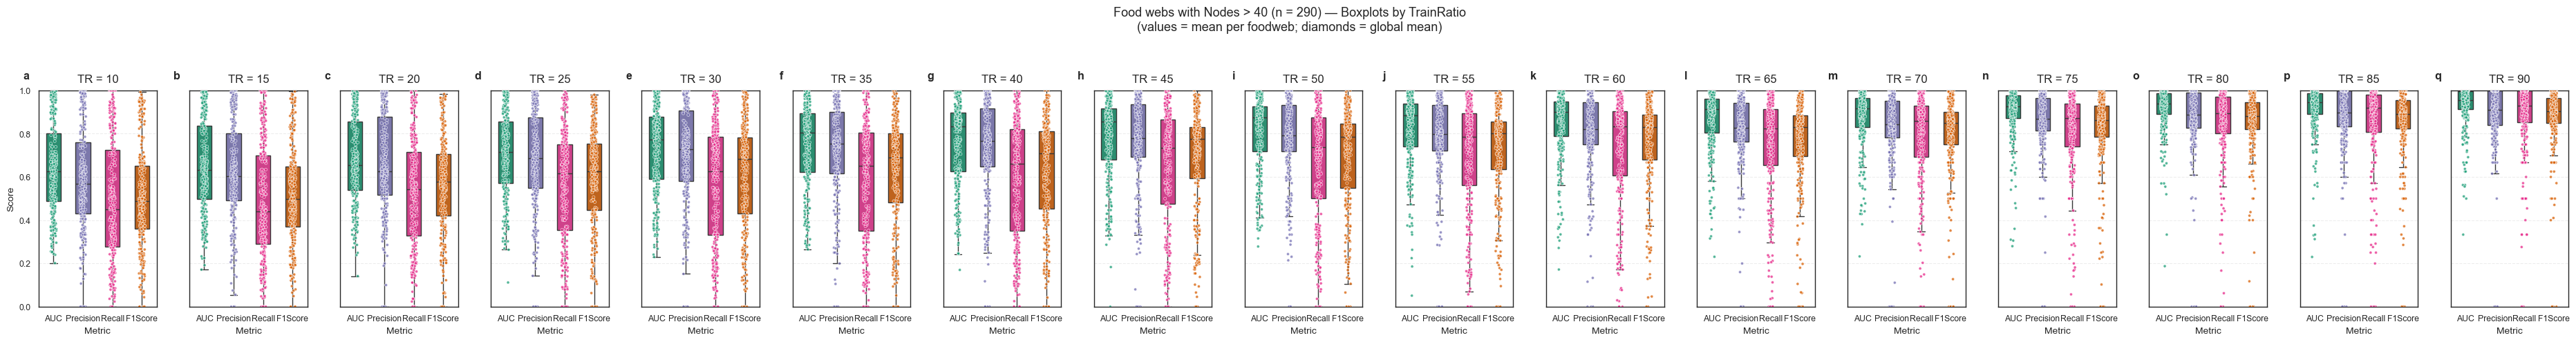

In [1]:
import os, glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# === Configuration ===
RESULTS_DIR = "../../../src/matlab/data/result_sweep_train_ratios_10-90/prediction_scores_logs/"
FOODWEB_CSV = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
SINGLE_FILE = None  # disable when using directory
METRICS = ["AUC", "Precision", "Recall", "F1Score"]
MAX_PLOTS = None   # ⬅️ still limits how many CSVs are read; set to None for all 290
NODES_THRESHOLD = 0

# === Utility functions ===
def derive_foodweb_from_filename(path: str) -> str:
    base = os.path.basename(path)
    name, _ = os.path.splitext(base)
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    name = "_".join([p for p in name.split("_") if p])
    return name

def normalize_fw_label(name: str) -> str:
    """
    Make foodweb labels comparable between results CSV and FOODWEB_CSV.
    - strip spaces
    - drop extension (.mat, .csv, etc.)
    - remove common suffixes: _tax_mass, _tax, _mass, _results, _random
    - collapse multiple underscores
    """
    name = str(name).strip()
    name, _ = os.path.splitext(name)   # remove .mat, .csv, etc.
    name = name.replace(" ", "_")
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    parts = [p for p in name.split("_") if p]
    return "_".join(parts)

def load_results(results_dir=None, single_file=None) -> pd.DataFrame:
    paths = []
    if results_dir and os.path.isdir(results_dir):
        paths = sorted(glob.glob(os.path.join(results_dir, "*.csv")))
        if MAX_PLOTS is not None:
            paths = paths[:MAX_PLOTS]
            print(f"[INFO] Limiting to first {len(paths)} CSV files for plotting.")
    if single_file and os.path.isfile(single_file):
        paths.append(single_file)
    if not paths:
        raise FileNotFoundError("No CSV files found. Check RESULTS_DIR or SINGLE_FILE.")

    frames = []
    for p in paths:
        try:
            df = pd.read_csv(p)
        except Exception as e:
            print(f"Skipping {p}: {e}")
            continue

        df.columns = [c.strip() for c in df.columns]
        # Normalize to upper for metrics, keep original for TrainRatio detection
        upper_map = {c: c.upper() for c in df.columns}
        df = df.rename(columns=upper_map)
        if "FOODWEB" not in df.columns:
            df["FOODWEB"] = derive_foodweb_from_filename(p)
        frames.append(df)

    if not frames:
        raise ValueError("No valid results loaded.")
    return pd.concat(frames, ignore_index=True)

# === Load (ALL train ratios kept) and preprocess ===
df = load_results(results_dir=RESULTS_DIR, single_file=SINGLE_FILE)

# === Load foodweb metadata and filter Nodes > NODES_THRESHOLD ===
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col_candidates = [c for c in meta.columns if c.lower() == "foodweb"]
nodes_col_candidates = [c for c in meta.columns if c.lower() == "nodes"]
if not fw_col_candidates or not nodes_col_candidates:
    raise ValueError("Could not find 'Foodweb' and 'Nodes' columns in FOODWEB_CSV.")

fw_col = fw_col_candidates[0]
nodes_col = nodes_col_candidates[0]

# Normalized keys on BOTH sides
meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df["FW_KEY"] = df["FOODWEB"].apply(normalize_fw_label)

# Foodwebs with Nodes > NODES_THRESHOLD in metadata
allowed_fw_keys = set(
    meta.loc[meta[nodes_col] > NODES_THRESHOLD, "FW_KEY"].unique()
)

print(f"[INFO] Foodwebs with Nodes > {NODES_THRESHOLD} in metadata: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results BEFORE filter: {df['FW_KEY'].nunique()}")

# Filter results
df = df[df["FW_KEY"].isin(allowed_fw_keys)].copy()
df.drop(columns=["FW_KEY"], inplace=True)

print(f"[INFO] Foodwebs in results AFTER filter: {df['FOODWEB'].nunique()}")

if df.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes > {NODES_THRESHOLD}.")

# === Normalize TrainRatio into a single 'TRAINRATIO' column (as percentages) ===
tr_candidates = [c for c in df.columns if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]]
if not tr_candidates:
    raise ValueError("No TrainRatio column found.")
tr_col = tr_candidates[0]
df["TRAINRATIO"] = pd.to_numeric(df[tr_col], errors="coerce")
if df["TRAINRATIO"].between(0, 1).all():
    df["TRAINRATIO"] = (df["TRAINRATIO"] * 100).round().astype(int)
else:
    df["TRAINRATIO"] = df["TRAINRATIO"].astype(int)

# === Auto-detect & sort TrainRatios present in the data ===
TRAIN_RATIOS_DETECTED = sorted(df["TRAINRATIO"].dropna().unique().astype(int).tolist())
if not TRAIN_RATIOS_DETECTED:
    raise ValueError("No valid TrainRatio values were detected.")

# === Prepare long form with TRAINRATIO kept ===
present = [m for m in METRICS if m.upper() in df.columns]
if not present:
    raise ValueError("None of the requested METRICS were found.")
long_frames = []
for m in present:
    mu = m.upper()
    tmp = df[["FOODWEB", "TRAINRATIO", mu]].rename(columns={mu: "Value"})
    tmp["Metric"] = m
    long_frames.append(tmp)
df_long = pd.concat(long_frames, ignore_index=True)

# === Aggregate: mean per FOODWEB, then global mean across foodwebs ===
df_web_means = (
    df_long
    .groupby(["FOODWEB", "TRAINRATIO", "Metric"], as_index=False)["Value"]
    .mean()
)

df_mean_overall = (
    df_web_means
    .groupby(["TRAINRATIO", "Metric"], as_index=False)["Value"]
    .mean()
    .rename(columns={"Value": "MeanValue"})
)

n_foodwebs = df_long["FOODWEB"].nunique()

# Custom palette (per metric, consistent across subplots)
metric_colors = {
    "AUC": "#1b9e77", "Precision": "#d95f02",
    "Recall": "#7570b3", "F1Score": "#e7298a",
}
palette = {k: metric_colors.get(k, "#5aa9e6") for k in df_long["Metric"].unique()}
order = list(present)
pal_list = [palette[m] for m in order]

# === Plot: single figure, columns = all detected TrainRatios ===
n_cols = max(1, len(TRAIN_RATIOS_DETECTED))
fig_w = max(7, 2.2 * n_cols)
fig, axes = plt.subplots(1, n_cols, figsize=(fig_w, 5), sharey=True)

if n_cols == 1:
    axes = [axes]

letters_all = [chr(ord('a') + i) for i in range(len(TRAIN_RATIOS_DETECTED))]

for j, tr in enumerate(TRAIN_RATIOS_DETECTED):
    ax = axes[j]
    sub_web = df_web_means[df_web_means["TRAINRATIO"] == tr]
    sub_mean = df_mean_overall[df_mean_overall["TRAINRATIO"] == tr]

    if sub_web.empty:
        ax.set_axis_off()
        ax.text(0.5, 0.5, f"No data\nTR={tr}", ha="center", va="center", fontsize=10)
        continue

    sns.boxplot(
        data=sub_web, x="Metric", y="Value",
        order=order, palette=pal_list,
        hue="Metric",
        width=0.5, showfliers=False,
        ax=ax
    )
    sns.stripplot(
        data=sub_web, x="Metric", y="Value",
        order=order, palette=pal_list,
        hue="Metric",
        dodge=False, jitter=0.10,
        size=3.0, alpha=0.75,
        edgecolor="white", linewidth=0.5,
        ax=ax
    )

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    if j < len(letters_all):
        ax.annotate(
            letters_all[j],
            xy=(0, 1), xycoords="axes fraction",
            xytext=(-10, 10), textcoords="offset points",
            ha="right", va="bottom",
            fontsize="large", fontweight="bold",
            annotation_clip=False
        )

    ax.set_title(f"TR = {tr}", fontsize=12, pad=8)
    ax.set_xlabel("Metric", fontsize=10)
    if j == 0:
        ax.set_ylabel("Score", fontsize=10)
    else:
        ax.set_ylabel("")

    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_locator(plt.MaxNLocator(6))
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)

fig.suptitle(
    f"Food webs with Nodes > 40 (n = {n_foodwebs}) — Boxplots by TrainRatio\n"
    f"(values = mean per foodweb; diamonds = global mean)",
    y=0.98, fontsize=13
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [2]:
# =========================
# Table 1: Mean performance per TrainRatio (global mean across food webs)
# =========================
# df_mean_overall columns: ["TRAINRATIO", "Metric", "MeanValue"]
# df_web_means columns:    ["FOODWEB", "TRAINRATIO", "Metric", "Value"]

# How many food webs contribute per TrainRatio (should usually be constant)
n_fw_by_tr = (
    df_web_means.groupby("TRAINRATIO")["FOODWEB"]
    .nunique()
    .rename("n_foodwebs")
    .reset_index()
)

# Wide table: rows=TrainRatio, cols=Metric, values=MeanValue
table_means = (
    df_mean_overall
    .pivot_table(index="TRAINRATIO", columns="Metric", values="MeanValue", aggfunc="mean")
    .reset_index()
    .merge(n_fw_by_tr, on="TRAINRATIO", how="left")
)

# Optional: enforce metric column order
metric_order = ["AUC", "Precision", "Recall", "F1Score"]
cols = ["TRAINRATIO"] + [m for m in metric_order if m in table_means.columns] + ["n_foodwebs"]
table_means = table_means[cols].sort_values("TRAINRATIO").reset_index(drop=True)

display(table_means)

,TRAINRATIO,AUC,Precision,Recall,F1Score,n_foodwebs
0,10,0.636329,0.590935,0.492125,0.497456,290
1,15,0.647097,0.619766,0.482070,0.511946,290
2,20,0.674691,0.659192,0.531323,0.563134,290
3,25,0.703608,0.679944,0.559994,0.590335,290
4,30,0.726189,0.703567,0.566136,0.604933,290
5,35,0.745936,0.723415,0.584739,0.624639,290
6,40,0.757779,0.732462,0.587722,0.629003,290
7,45,0.783433,0.758501,0.645094,0.677483,290
8,50,0.803986,0.776017,0.662828,0.694031,290
9,55,0.821401,0.786288,0.697911,0.721774,290


In [3]:
# =========================
# Table 2 (optional): Dispersion across food webs per TrainRatio × metric
# =========================
stats_long = (
    df_web_means
    .groupby(["TRAINRATIO", "Metric"])["Value"]
    .agg(mean="mean", std="std")
    .reset_index()
)

# Wide version: columns like AUC_mean, AUC_std, ...
stats_wide = stats_long.pivot_table(
    index="TRAINRATIO",
    columns="Metric",
    values=["mean", "std"],
    aggfunc="first",
)

# Flatten multi-index columns
stats_wide.columns = [f"{metric}_{stat}" for stat, metric in stats_wide.columns]
stats_wide = stats_wide.reset_index().sort_values("TRAINRATIO").reset_index(drop=True)

# Format float columns to 4 decimals for display
stats_wide = stats_wide.round(4)

display(stats_wide)

,TRAINRATIO,AUC_mean,F1Score_mean,Precision_mean,Recall_mean,AUC_std,F1Score_std,Precision_std,Recall_std
0,10,0.6363,0.4975,0.5909,0.4921,0.2081,0.2348,0.2469,0.2865
1,15,0.6471,0.5119,0.6198,0.4821,0.2109,0.2283,0.2365,0.2637
2,20,0.6747,0.5631,0.6592,0.5313,0.1987,0.2264,0.2281,0.2559
3,25,0.7036,0.5903,0.6799,0.5600,0.1934,0.2325,0.2338,0.2589
4,30,0.7262,0.6049,0.7036,0.5661,0.1970,0.2468,0.2229,0.2718
5,35,0.7459,0.6246,0.7234,0.5847,0.1927,0.2482,0.2265,0.2751
6,40,0.7578,0.6290,0.7325,0.5877,0.1915,0.2513,0.2218,0.2819
7,45,0.7834,0.6775,0.7585,0.6451,0.1923,0.2445,0.2128,0.2763
8,50,0.8040,0.6940,0.7760,0.6628,0.1723,0.2313,0.2009,0.2690
9,55,0.8214,0.7218,0.7863,0.6979,0.1695,0.2268,0.1916,0.2602


In [15]:
# =========================
# Table 2: Dispersion across food webs per TrainRatio × metric
# (format: mean (± std))
# =========================
metric_order = ["AUC", "Precision", "Recall", "F1Score"]

stats_long = (
    df_web_means
    .groupby(["TRAINRATIO", "Metric"])["Value"]
    .agg(mean="mean", std="std")
    .reset_index()
)

mean_wide = stats_long.pivot(index="TRAINRATIO", columns="Metric", values="mean")
std_wide  = stats_long.pivot(index="TRAINRATIO", columns="Metric", values="std")

def fmt(m, s):
    if pd.isna(m):
        return ""
    if pd.isna(s):
        return f"{m:.4f}"
    return f"{m:.4f} (± {s:.4f})"

# Vectorized-ish formatting
stats_fmt = mean_wide.copy()

for col in stats_fmt.columns:
    stats_fmt[col] = [
        fmt(m, s) for m, s in zip(mean_wide[col].to_numpy(), std_wide[col].to_numpy())
    ]

stats_fmt = (
    stats_fmt
    .reset_index()
    .sort_values("TRAINRATIO")
    .reset_index(drop=True)
)

stats_fmt = stats_fmt[["TRAINRATIO"] + [m for m in metric_order if m in stats_fmt.columns]]
stats_fmt = stats_fmt.rename(columns={"TRAINRATIO": "TrainRatio (%)"})
# stats_fmt.columns.name = None

display(stats_fmt)

Metric,TrainRatio (%),AUC,Precision,Recall,F1Score
0,10,0.6363 (± 0.2081),0.5909 (± 0.2469),0.4921 (± 0.2865),0.4975 (± 0.2348)
1,15,0.6471 (± 0.2109),0.6198 (± 0.2365),0.4821 (± 0.2637),0.5119 (± 0.2283)
2,20,0.6747 (± 0.1987),0.6592 (± 0.2281),0.5313 (± 0.2559),0.5631 (± 0.2264)
3,25,0.7036 (± 0.1934),0.6799 (± 0.2338),0.5600 (± 0.2589),0.5903 (± 0.2325)
4,30,0.7262 (± 0.1970),0.7036 (± 0.2229),0.5661 (± 0.2718),0.6049 (± 0.2468)
5,35,0.7459 (± 0.1927),0.7234 (± 0.2265),0.5847 (± 0.2751),0.6246 (± 0.2482)
6,40,0.7578 (± 0.1915),0.7325 (± 0.2218),0.5877 (± 0.2819),0.6290 (± 0.2513)
7,45,0.7834 (± 0.1923),0.7585 (± 0.2128),0.6451 (± 0.2763),0.6775 (± 0.2445)
8,50,0.8040 (± 0.1723),0.7760 (± 0.2009),0.6628 (± 0.2690),0.6940 (± 0.2313)
9,55,0.8214 (± 0.1695),0.7863 (± 0.1916),0.6979 (± 0.2602),0.7218 (± 0.2268)


Filtered food webs by size: kept 160 / 290 (>= 40 nodes).


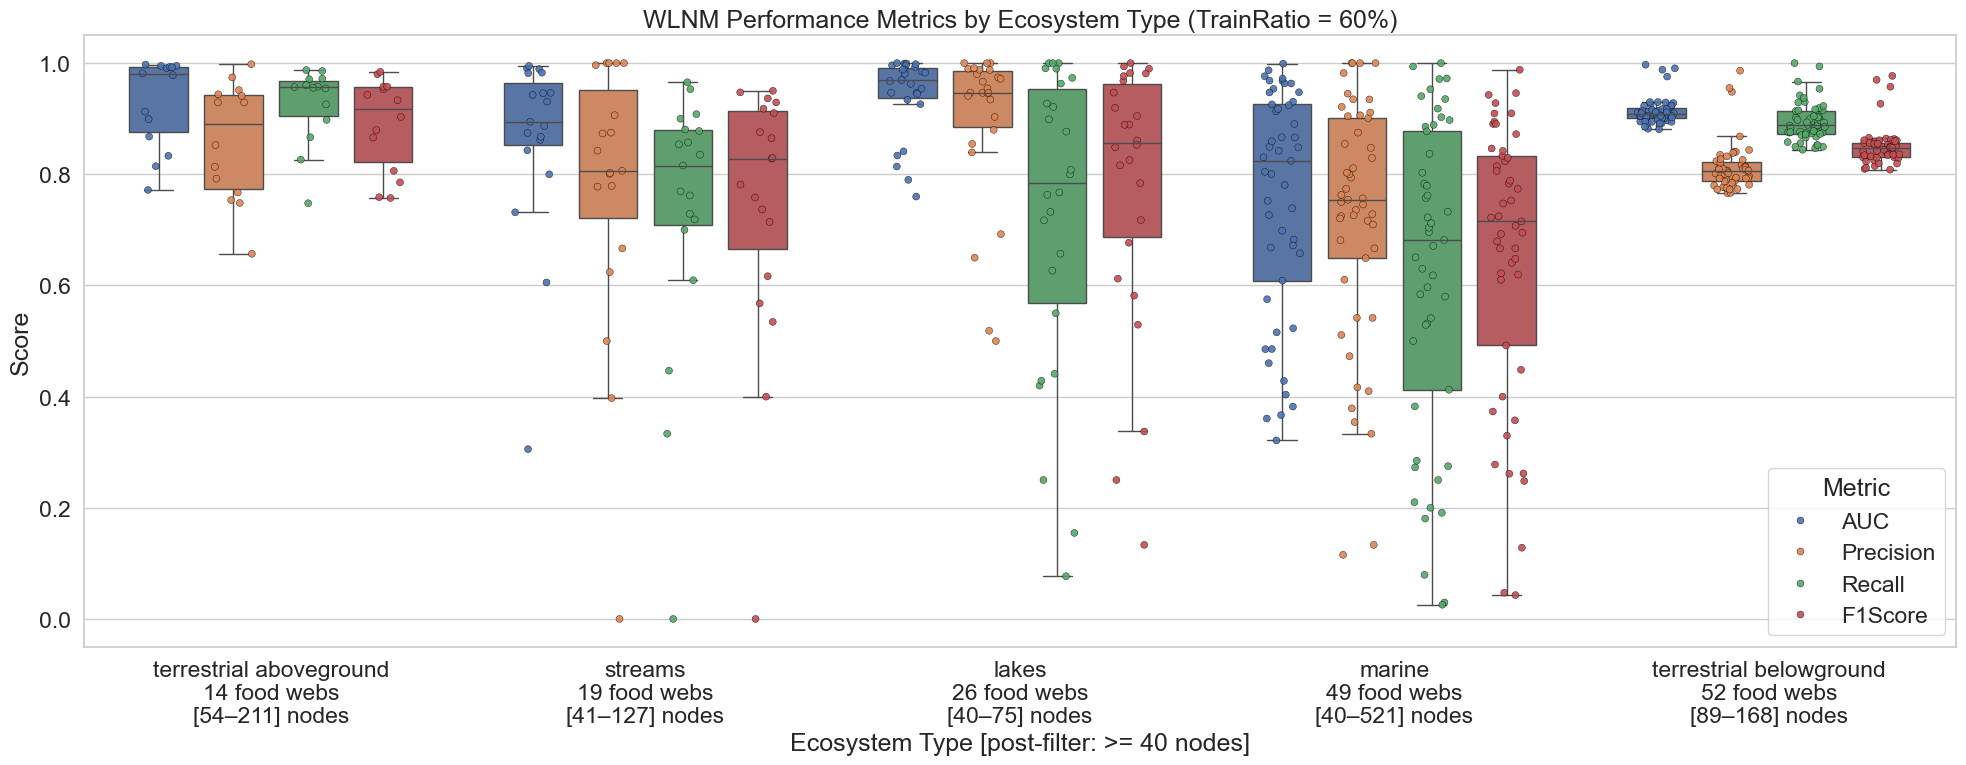

In [ ]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === Paths ===
results_dir = "../../../src/matlab/data/result_sweep_train_ratios_10-90/prediction_scores_logs"
ecosystem_file = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

METRIC_ORDER = ["AUC", "Precision", "Recall", "F1Score"]

# Take the first 4 colors from seaborn "deep" and map them in the exact order above
deep4 = sns.color_palette("deep", 4)  # [blue, orange, green, red] in seaborn's deep
metric_palette = dict(zip(METRIC_ORDER, deep4))

# === Filtering threshold ===
MIN_NODES = 40  # exclude food webs smaller than this

# === Load ecosystem metadata ===
df_ecosystem = pd.read_csv(ecosystem_file)

# --- Detect a node-count column robustly ---
def _normalize(s: str) -> str:
    return (
        s.strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

candidates = {
    "n_nodes", "num_nodes", "nodes", "nodecount", "n", "s",
    "species", "numspecies", "numberofspecies", "speciescount"
}
norm_map = {_normalize(c): c for c in df_ecosystem.columns}
node_col = None
for k in candidates:
    if k in norm_map:
        node_col = norm_map[k]
        break

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in ecosystem metadata. "
        "Please add one (e.g., 'S', 'nodes', 'num_species', 'node_count')."
    )

# === Load result CSVs and stack ===
csv_files = glob.glob(os.path.join(results_dir, "*_results_random.csv"))
dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    filename = os.path.basename(file)
    foodweb = filename.split("_results_")[0]
    df["Foodweb"] = foodweb
    dfs.append(df)

if not dfs:
    raise RuntimeError("No result CSV found. Check the path or pattern.")

df_all = pd.concat(dfs, ignore_index=True)

# === Merge metrics with ecosystem metadata (ecosystem + node count) ===
meta_cols = ["Foodweb", "EcosystemType", node_col]
df_merged = pd.merge(df_all, df_ecosystem[meta_cols], on="Foodweb", how="left")

# === Apply node-count filter ===
before_n = df_merged["Foodweb"].nunique()
df_merged = df_merged[df_merged[node_col] >= MIN_NODES].copy()
after_n = df_merged["Foodweb"].nunique()
print(f"Filtered food webs by size: kept {after_n} / {before_n} (>= {MIN_NODES} nodes).")

# === Prepare data for plotting ===
df_plot = df_merged.melt(
    id_vars=["Foodweb", "TrainRatio", "EcosystemType", "Iteration"],
    value_vars=["AUC", "Precision", "Recall", "F1Score"],
    var_name="Metric",
    value_name="Value"
)

# Cast TrainRatio to string for cleaner facet/legend titles if desired
df_plot["TrainRatio"] = df_plot["TrainRatio"].astype(str)

# === Order ecosystems by count (after filtering) ===
ecosystem_order = (
    df_merged[["Foodweb", "EcosystemType"]]
    .drop_duplicates()
    .groupby("EcosystemType")
    .size()
    .sort_values()
    .index
    .tolist()
)

# === Build dynamic x-axis labels with counts and node ranges (after filtering) ===
def make_label(group: pd.DataFrame) -> str:
    n_webs = group["Foodweb"].nunique()
    node_min = int(group[node_col].min())
    node_max = int(group[node_col].max())
    name = group.name  # EcosystemType value
    return f"{name}\n{n_webs} food webs\n[{node_min}–{node_max}] nodes"

labels_map = {}
for eco in ecosystem_order:
    grp = df_merged[df_merged["EcosystemType"] == eco]
    if grp.empty:
        continue
    grp.name = eco
    labels_map[eco] = make_label(grp)

custom_labels = [labels_map[eco] for eco in ecosystem_order if eco in labels_map]

from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch

def shrink_seaborn_boxes(ax, factor: float = 0.85) -> None:
    """
    Shrink box widths (and their whisker/cap/median lines) around each box center.
    This creates extra gap between hue boxes inside each category.
    """
    # Seaborn boxes are usually PathPatch objects stored in ax.patches
    box_patches = [p for p in ax.patches if isinstance(p, PathPatch)]
    if not box_patches:
        print("[WARN] No box patches found to shrink.")
        return

    # Whiskers/caps/medians are in ax.lines (typically 6 per box, but can vary by version)
    lines = ax.lines
    n_boxes = len(box_patches)
    lines_per_box = (len(lines) // n_boxes) if (n_boxes > 0 and len(lines) % n_boxes == 0) else 6

    for i, patch in enumerate(box_patches):
        path = patch.get_path()
        verts = path.vertices
        xs = verts[:, 0].copy()
        xmid = (xs.min() + xs.max()) / 2.0

        # shrink the box polygon
        verts[:, 0] = xmid + (xs - xmid) * factor
        patch.set_path(MplPath(verts, path.codes))

        # shrink corresponding lines (whiskers/caps/median) for this box
        start = i * lines_per_box
        end = min(start + lines_per_box, len(lines))
        for line in lines[start:end]:
            xdata = line.get_xdata()
            line.set_xdata(xmid + (xdata - xmid) * factor)

# === Plot ONLY TrainRatio = 60% and overlay points ===
sns.set_theme(style="whitegrid", font_scale=1.5)

# Robust filter to 60% even if stored as "60" or "60.0"
subset = df_plot[df_plot["TrainRatio"].astype(float) == 60.0].copy()
if subset.empty:
    raise RuntimeError("No rows for TrainRatio = 60.0. Check how TrainRatio is stored.")

subset["Metric"] = pd.Categorical(subset["Metric"], categories=METRIC_ORDER, ordered=True)

plt.figure(figsize=(20, 8))

# Boxplot without outliers (keeps view clean for points)
ax = sns.boxplot(
    data=subset,
    x="EcosystemType",
    y="Value",
    hue="Metric",
    hue_order=METRIC_ORDER,
    palette=metric_palette,
    showfliers=False,
    order=ecosystem_order,
)

# Create inner gap between the hue boxplots within each ecosystem
shrink_seaborn_boxes(ax, factor=0.78)  # try 0.75–0.85

# Overlay individual data points (stripplot = jittered dots).
# Use small alpha + linewidth for readability; dodge=True to separate hues.
sns.stripplot(
    data=subset,
    x="EcosystemType",
    y="Value",
    hue="Metric",
    hue_order=METRIC_ORDER,
    palette=metric_palette,
    dodge=True,
    jitter=0.20,
    alpha=0.90,
    linewidth=0.3,
    edgecolor="black",
    order=ecosystem_order,
    zorder=2,
)

# De-duplicate the legend (boxplot + stripplot both add entries)
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))  # keeps last occurrence per label
ax.legend(uniq.values(), uniq.keys(), title="Metric", frameon=True, loc='lower right')

ax.set_title("WLNM Performance Metrics by Ecosystem Type (TrainRatio = 60%)")
ax.set_ylabel("Score")
ax.set_xlabel(f"Ecosystem Type [post-filter: >= {MIN_NODES} nodes]")
ax.set_xticks(range(len(custom_labels)))
ax.set_xticklabels(custom_labels)
plt.tight_layout()
plt.show()

[INFO] Foodwebs with Nodes >= 40 in metadata: 160
[INFO] Baseline: foodwebs in results BEFORE filter: 290
[INFO] Baseline: foodwebs in results AFTER filter: 160
[INFO] Backbone: foodwebs in results BEFORE filter: 290
[INFO] Backbone: foodwebs in results AFTER filter: 160


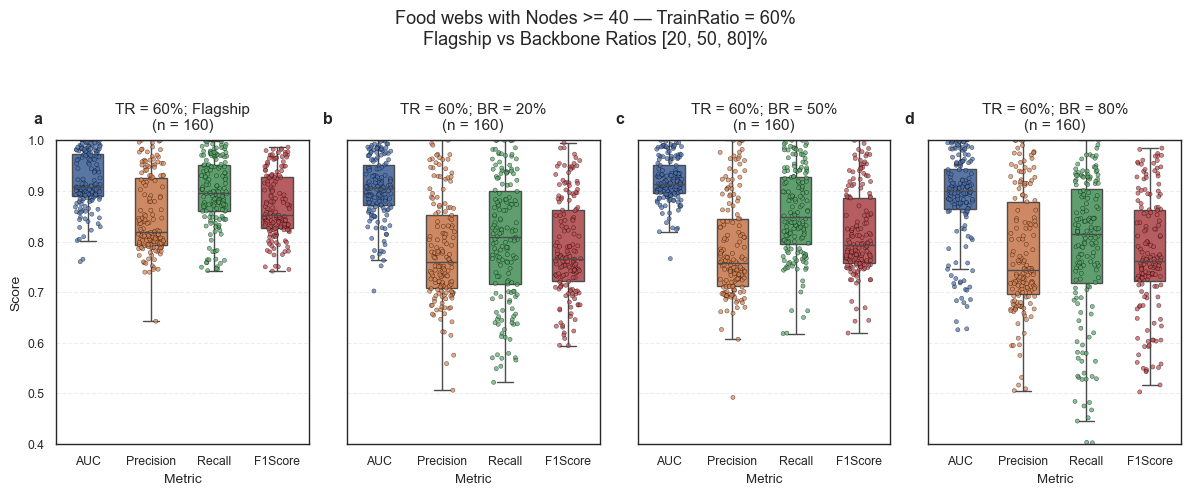

In [4]:
import os, glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# === Configuration ===
RESULTS_DIR = "../../../src/matlab/data/result_sweep_train_ratios_290/prediction_scores_logs/"
RESULTS_DIR_BB = "../../../src/matlab/data/result_sweep_trainRatio_60-80_backboneRatio_20-50-80/prediction_scores_logs/"
FOODWEB_CSV = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
SINGLE_FILE = None  # set to a CSV path if you want to plot a single file for the baseline
METRICS = ["AUC", "Precision", "Recall", "F1Score"]
MAX_PLOTS = None    # set to an integer to limit how many CSVs are read
NODES_THRESHOLD = 40
TARGET_TR = 60                  # focus on TrainRatio = 60% only
BACKBONE_RATIOS = [20, 50, 80]  # backbone ratios to compare (all at TR=60%)

# === Utility functions ===
def derive_foodweb_from_filename(path: str) -> str:
    base = os.path.basename(path)
    name, _ = os.path.splitext(base)
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    name = "_".join([p for p in name.split("_") if p])
    return name

def normalize_fw_label(name: str) -> str:
    """
    Make foodweb labels comparable between results CSV and FOODWEB_CSV.
    - strip spaces
    - drop extension (.mat, .csv, etc.)
    - remove common suffixes: _tax_mass, _tax, _mass, _results, _random
    - collapse multiple underscores
    """
    name = str(name).strip()
    name, _ = os.path.splitext(name)   # remove .mat, .csv, etc.
    name = name.replace(" ", "_")
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    parts = [p for p in name.split("_") if p]
    return "_".join(parts)

def load_results(results_dir=None, single_file=None) -> pd.DataFrame:
    paths = []
    if results_dir and os.path.isdir(results_dir):
        paths = sorted(glob.glob(os.path.join(results_dir, "*.csv")))
        if MAX_PLOTS is not None:
            paths = paths[:MAX_PLOTS]
            print(f"[INFO] Limiting to first {len(paths)} CSV files for plotting.")
    if single_file and os.path.isfile(single_file):
        paths.append(single_file)
    if not paths:
        raise FileNotFoundError("No CSV files found. Check RESULTS_DIR or SINGLE_FILE.")

    frames = []
    for p in paths:
        try:
            df = pd.read_csv(p)
        except Exception as e:
            print(f"Skipping {p}: {e}")
            continue

        df.columns = [c.strip() for c in df.columns]
        # Normalize to upper for metrics, keep original for TrainRatio detection
        upper_map = {c: c.upper() for c in df.columns}
        df = df.rename(columns=upper_map)
        if "FOODWEB" not in df.columns:
            df["FOODWEB"] = derive_foodweb_from_filename(p)
        frames.append(df)

    if not frames:
        raise ValueError("No valid results loaded.")
    return pd.concat(frames, ignore_index=True)

# =====================================================================
# 1) Load baseline (no-backbone) results
# =====================================================================
df_base = load_results(results_dir=RESULTS_DIR, single_file=SINGLE_FILE)

# === Load foodweb metadata and filter Nodes >= NODES_THRESHOLD ===
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col_candidates = [c for c in meta.columns if c.lower() == "foodweb"]
nodes_col_candidates = [c for c in meta.columns if c.lower() == "nodes"]
if not fw_col_candidates or not nodes_col_candidates:
    raise ValueError("Could not find 'Foodweb' and 'Nodes' columns in FOODWEB_CSV.")

fw_col = fw_col_candidates[0]
nodes_col = nodes_col_candidates[0]

# Normalized keys on BOTH sides
meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)

# Allowed food webs by node threshold
allowed_fw_keys = set(
    meta.loc[meta[nodes_col] >= NODES_THRESHOLD, "FW_KEY"].unique()
)

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD} in metadata: {len(allowed_fw_keys)}")

# --- Filter baseline by node threshold ---
df_base["FW_KEY"] = df_base["FOODWEB"].apply(normalize_fw_label)
print(f"[INFO] Baseline: foodwebs in results BEFORE filter: {df_base['FW_KEY'].nunique()}")

df_base = df_base[df_base["FW_KEY"].isin(allowed_fw_keys)].copy()
df_base.drop(columns=["FW_KEY"], inplace=True)

print(f"[INFO] Baseline: foodwebs in results AFTER filter: {df_base['FOODWEB'].nunique()}")

if df_base.empty:
    raise ValueError(f"No baseline foodwebs left after filtering Nodes > {NODES_THRESHOLD}.")

# === Normalize TrainRatio into a single 'TRAINRATIO' column (as percentages) ===
tr_candidates_base = [c for c in df_base.columns if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]]
if not tr_candidates_base:
    raise ValueError("No TrainRatio column found in baseline results.")
tr_col_base = tr_candidates_base[0]

df_base["TRAINRATIO"] = pd.to_numeric(df_base[tr_col_base], errors="coerce")
if df_base["TRAINRATIO"].between(0, 1).all():
    df_base["TRAINRATIO"] = (df_base["TRAINRATIO"] * 100).round().astype(int)
else:
    df_base["TRAINRATIO"] = df_base["TRAINRATIO"].astype(int)

# Keep only TARGET_TR in baseline
df_base = df_base[df_base["TRAINRATIO"] == TARGET_TR].copy()
if df_base.empty:
    raise ValueError(f"No baseline rows with TRAINRATIO = {TARGET_TR}.")

# === Prepare long form (baseline) ===
present = [m for m in METRICS if m.upper() in df_base.columns]
if not present:
    raise ValueError("None of the requested METRICS were found in baseline results.")

long_frames_base = []
for m in present:
    mu = m.upper()
    tmp = df_base[["FOODWEB", "TRAINRATIO", mu]].rename(columns={mu: "Value"})
    tmp["Metric"] = m
    long_frames_base.append(tmp)
df_long_base = pd.concat(long_frames_base, ignore_index=True)

# === Aggregate: mean per FOODWEB (baseline) ===
df_web_means_base = (
    df_long_base
    .groupby(["FOODWEB", "Metric"], as_index=False)["Value"]
    .mean()
)

n_foodwebs_base = df_long_base["FOODWEB"].nunique()

# =====================================================================
# 2) Load backbone results (TR=60%, BR in BACKBONE_RATIOS)
# =====================================================================
df_bb = load_results(results_dir=RESULTS_DIR_BB, single_file=None)

# Filter by same node threshold
df_bb["FW_KEY"] = df_bb["FOODWEB"].apply(normalize_fw_label)
print(f"[INFO] Backbone: foodwebs in results BEFORE filter: {df_bb['FW_KEY'].nunique()}")

df_bb = df_bb[df_bb["FW_KEY"].isin(allowed_fw_keys)].copy()
df_bb.drop(columns=["FW_KEY"], inplace=True)

print(f"[INFO] Backbone: foodwebs in results AFTER filter: {df_bb['FOODWEB'].nunique()}")

if df_bb.empty:
    raise ValueError(f"No backbone foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")

# Normalize TrainRatio in backbone results
tr_candidates_bb = [c for c in df_bb.columns if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]]
if not tr_candidates_bb:
    raise ValueError("No TrainRatio column found in backbone results.")
tr_col_bb = tr_candidates_bb[0]

df_bb["TRAINRATIO"] = pd.to_numeric(df_bb[tr_col_bb], errors="coerce")
if df_bb["TRAINRATIO"].between(0, 1).all():
    df_bb["TRAINRATIO"] = (df_bb["TRAINRATIO"] * 100).round().astype(int)
else:
    df_bb["TRAINRATIO"] = df_bb["TRAINRATIO"].astype(int)

df_bb = df_bb[df_bb["TRAINRATIO"] == TARGET_TR].copy()
if df_bb.empty:
    raise ValueError(f"No backbone rows with TRAINRATIO = {TARGET_TR}.")

# Normalize BackboneRatio
bb_candidates = [c for c in df_bb.columns if c.lower() in ["backboneratio", "backbone_ratio"]]
if not bb_candidates:
    raise ValueError("No BackboneRatio column found in backbone results.")
bb_col = bb_candidates[0]

df_bb["BACKBONERATIO"] = pd.to_numeric(df_bb[bb_col], errors="coerce")
if df_bb["BACKBONERATIO"].between(0, 1).all():
    df_bb["BACKBONERATIO"] = (df_bb["BACKBONERATIO"] * 100).round().astype(int)
else:
    df_bb["BACKBONERATIO"] = df_bb["BACKBONERATIO"].astype(int)

# Filter to desired backbone ratios
df_bb = df_bb[df_bb["BACKBONERATIO"].isin(BACKBONE_RATIOS)].copy()
if df_bb.empty:
    raise ValueError(f"No backbone rows with BACKBONERATIO in {BACKBONE_RATIOS}.")

# Ensure metrics exist also in backbone
missing_metrics = [m for m in present if m.upper() not in df_bb.columns]
if missing_metrics:
    raise ValueError(f"Backbone results missing metrics: {missing_metrics}")

# Long form for backbone (include BACKBONERATIO)
long_frames_bb = []
for m in present:
    mu = m.upper()
    tmp = df_bb[["FOODWEB", "TRAINRATIO", "BACKBONERATIO", mu]].rename(columns={mu: "Value"})
    tmp["Metric"] = m
    long_frames_bb.append(tmp)
df_long_bb = pd.concat(long_frames_bb, ignore_index=True)

# Aggregate for backbone (per foodweb, per backbone ratio)
df_web_means_bb = (
    df_long_bb
    .groupby(["FOODWEB", "BACKBONERATIO", "Metric"], as_index=False)["Value"]
    .mean()
)

# n foodwebs per backbone ratio
n_foodwebs_bb = {
    br: df_long_bb.loc[df_long_bb["BACKBONERATIO"] == br, "FOODWEB"].nunique()
    for br in BACKBONE_RATIOS
}

# =====================================================================
# 3) Plotting — baseline + backbone BR in BACKBONE_RATIOS
# =====================================================================

# Match the first snippet's look
sns.set_theme(style="white", context="paper")

METRIC_ORDER = ["AUC", "Precision", "Recall", "F1Score"]
deep4 = sns.color_palette("deep", 4)  # [blue, orange, green, red]
metric_palette = dict(zip(METRIC_ORDER, deep4))

order = [m for m in METRIC_ORDER if m in present]  # keep your present logic, but fixed order

metric_colors = {
    "AUC": "#1b9e77", "Precision": "#d95f02",
    "Recall": "#7570b3", "F1Score": "#e7298a",
}
palette = {k: metric_colors.get(k, "#5aa9e6") for k in df_long_base["Metric"].unique()}
order = list(present)
pal_list = [palette[m] for m in order]

n_panels = 1 + len(BACKBONE_RATIOS)
fig, axes = plt.subplots(1, n_panels, figsize=(3 * n_panels, 5), sharey=True)

if n_panels == 1:
    axes = [axes]

panel_letters = [chr(ord("a") + i) for i in range(n_panels)]

# Common plotting kwargs to replicate the "box + points" style
BOX_KW = dict(
    order=order,
    palette=metric_palette,
    width=0.5,
    showfliers=False,
    hue="Metric",
    hue_order=order,
    legend=False,
)

POINT_KW = dict(
    order=order,
    palette=metric_palette,
    jitter=0.20,
    alpha=0.70,
    size=3.0,
    edgecolor="black",
    linewidth=0.3,
    zorder=2,
    hue="Metric",
    hue_order=order,
    legend=False,
)

# --- Panel 0: baseline ---
ax = axes[0]
sub_web = df_web_means_base

sns.boxplot(
    data=sub_web, x="Metric", y="Value",
    ax=ax, **BOX_KW
)
sns.stripplot(
    data=sub_web, x="Metric", y="Value",
    ax=ax, **POINT_KW
)

# (No legend should exist now, but keep your logic harmlessly)
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.annotate(
    panel_letters[0],
    xy=(0, 1), xycoords="axes fraction",
    xytext=(-10, 10), textcoords="offset points",
    ha="right", va="bottom",
    fontsize="large", fontweight="bold",
    annotation_clip=False
)

ax.set_title(f"TR = {TARGET_TR}%; Flagship\n(n = {n_foodwebs_base})", fontsize=11, pad=8)
ax.set_xlabel("Metric", fontsize=10)
ax.set_ylabel("Score", fontsize=10)
ax.set_ylim(0.4, 1.0)
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.grid(True, axis="y", linestyle="--", alpha=0.35)

# --- Panels 1..k: backbone BR in BACKBONE_RATIOS ---
for i, br in enumerate(BACKBONE_RATIOS, start=1):
    ax = axes[i]
    sub_web = df_web_means_bb[df_web_means_bb["BACKBONERATIO"] == br]

    sns.boxplot(
        data=sub_web, x="Metric", y="Value",
        ax=ax, **BOX_KW
    )
    sns.stripplot(
        data=sub_web, x="Metric", y="Value",
        ax=ax, **POINT_KW
    )

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    ax.annotate(
        panel_letters[i],
        xy=(0, 1), xycoords="axes fraction",
        xytext=(-10, 10), textcoords="offset points",
        ha="right", va="bottom",
        fontsize="large", fontweight="bold",
        annotation_clip=False
    )

    ax.set_title(
        f"TR = {TARGET_TR}%; BR = {br}%\n(n = {n_foodwebs_bb.get(br, 0)})",
        fontsize=11,
        pad=8
    )
    # ax.set_xlabel("Metric", fontsize=10)
    ax.set_ylabel("" if i > 0 else "Score")
    ax.set_ylim(0.4, 1.0)
    ax.yaxis.set_major_locator(plt.MaxNLocator(6))
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)

fig.suptitle(
    f"Food webs with Nodes >= {NODES_THRESHOLD} — TrainRatio = {TARGET_TR}%\n"
    f"Flagship vs Backbone Ratios {BACKBONE_RATIOS}%",
    y=0.98, fontsize=13
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

[INFO] Foodwebs with Nodes >= 40 in metadata: 160
[INFO] Baseline: foodwebs in results BEFORE filter: 290
[INFO] Baseline: foodwebs in results AFTER filter: 160
[INFO] Backbone: foodwebs in results BEFORE filter: 290
[INFO] Backbone: foodwebs in results AFTER filter: 160


/var/folders/37/n26ttb4n16xb2c3z17l2p6r00000gp/T/ipykernel_65523/3924243666.py:309: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cond_order, rotation=0)
/var/folders/37/n26ttb4n16xb2c3z17l2p6r00000gp/T/ipykernel_65523/3924243666.py:309: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cond_order, rotation=0)
/var/folders/37/n26ttb4n16xb2c3z17l2p6r00000gp/T/ipykernel_65523/3924243666.py:309: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cond_order, rotation=0)
/var/folders/37/n26ttb4n16xb2c3z17l2p6r00000gp/T/ipykernel_65523/3924243666.py:309: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklab

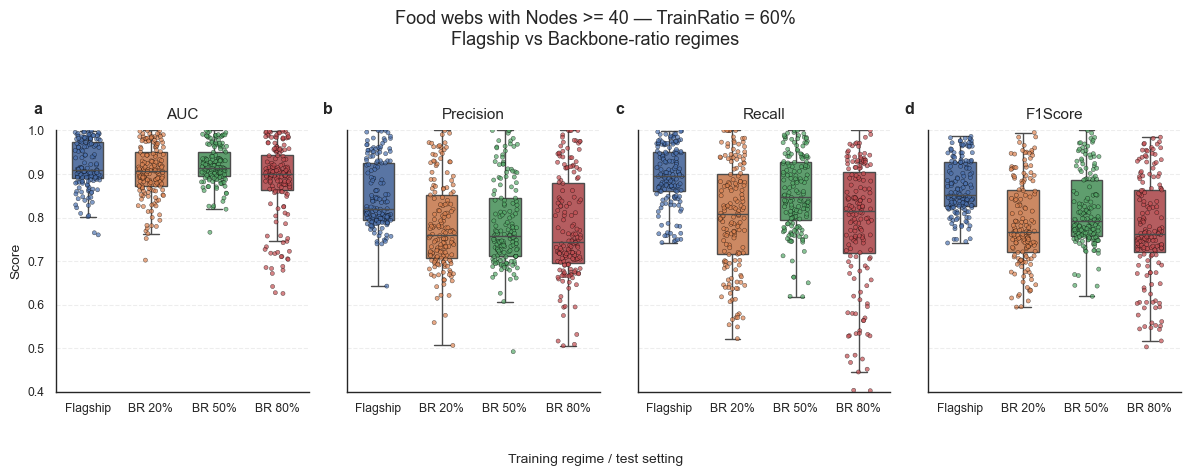

In [1]:
import os, glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# === Configuration ===
RESULTS_DIR = "../../../src/matlab/data/result_sweep_train_ratios_290/prediction_scores_logs/"
RESULTS_DIR_BB = "../../../src/matlab/data/result_sweep_trainRatio_60-80_backboneRatio_20-50-80/prediction_scores_logs/"
FOODWEB_CSV = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
SINGLE_FILE = None  # set to a CSV path if you want to plot a single file for the baseline
METRICS = ["AUC", "Precision", "Recall", "F1Score"]
MAX_PLOTS = None    # set to an integer to limit how many CSVs are read
NODES_THRESHOLD = 40
TARGET_TR = 60                  # focus on TrainRatio = 60% only
BACKBONE_RATIOS = [20, 50, 80]  # backbone ratios to compare (all at TR=60%)

# === Utility functions ===
def derive_foodweb_from_filename(path: str) -> str:
    base = os.path.basename(path)
    name, _ = os.path.splitext(base)
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    name = "_".join([p for p in name.split("_") if p])
    return name

def normalize_fw_label(name: str) -> str:
    """
    Make foodweb labels comparable between results CSV and FOODWEB_CSV.
    - strip spaces
    - drop extension (.mat, .csv, etc.)
    - remove common suffixes: _tax_mass, _tax, _mass, _results, _random
    - collapse multiple underscores
    """
    name = str(name).strip()
    name, _ = os.path.splitext(name)   # remove .mat, .csv, etc.
    name = name.replace(" ", "_")
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    parts = [p for p in name.split("_") if p]
    return "_".join(parts)

def load_results(results_dir=None, single_file=None) -> pd.DataFrame:
    paths = []
    if results_dir and os.path.isdir(results_dir):
        paths = sorted(glob.glob(os.path.join(results_dir, "*.csv")))
        if MAX_PLOTS is not None:
            paths = paths[:MAX_PLOTS]
            print(f"[INFO] Limiting to first {len(paths)} CSV files for plotting.")
    if single_file and os.path.isfile(single_file):
        paths.append(single_file)
    if not paths:
        raise FileNotFoundError("No CSV files found. Check RESULTS_DIR or SINGLE_FILE.")

    frames = []
    for p in paths:
        try:
            df = pd.read_csv(p)
        except Exception as e:
            print(f"Skipping {p}: {e}")
            continue

        df.columns = [c.strip() for c in df.columns]
        # Normalize to upper for metrics, keep original for TrainRatio detection
        upper_map = {c: c.upper() for c in df.columns}
        df = df.rename(columns=upper_map)
        if "FOODWEB" not in df.columns:
            df["FOODWEB"] = derive_foodweb_from_filename(p)
        frames.append(df)

    if not frames:
        raise ValueError("No valid results loaded.")
    return pd.concat(frames, ignore_index=True)

# =====================================================================
# 1) Load baseline (no-backbone) results
# =====================================================================
df_base = load_results(results_dir=RESULTS_DIR, single_file=SINGLE_FILE)

# === Load foodweb metadata and filter Nodes >= NODES_THRESHOLD ===
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col_candidates = [c for c in meta.columns if c.lower() == "foodweb"]
nodes_col_candidates = [c for c in meta.columns if c.lower() == "nodes"]
if not fw_col_candidates or not nodes_col_candidates:
    raise ValueError("Could not find 'Foodweb' and 'Nodes' columns in FOODWEB_CSV.")

fw_col = fw_col_candidates[0]
nodes_col = nodes_col_candidates[0]

# Normalized keys on BOTH sides
meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)

# Allowed food webs by node threshold
allowed_fw_keys = set(
    meta.loc[meta[nodes_col] >= NODES_THRESHOLD, "FW_KEY"].unique()
)

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD} in metadata: {len(allowed_fw_keys)}")

# --- Filter baseline by node threshold ---
df_base["FW_KEY"] = df_base["FOODWEB"].apply(normalize_fw_label)
print(f"[INFO] Baseline: foodwebs in results BEFORE filter: {df_base['FW_KEY'].nunique()}")

df_base = df_base[df_base["FW_KEY"].isin(allowed_fw_keys)].copy()
df_base.drop(columns=["FW_KEY"], inplace=True)

print(f"[INFO] Baseline: foodwebs in results AFTER filter: {df_base['FOODWEB'].nunique()}")

if df_base.empty:
    raise ValueError(f"No baseline foodwebs left after filtering Nodes > {NODES_THRESHOLD}.")

# === Normalize TrainRatio into a single 'TRAINRATIO' column (as percentages) ===
tr_candidates_base = [c for c in df_base.columns if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]]
if not tr_candidates_base:
    raise ValueError("No TrainRatio column found in baseline results.")
tr_col_base = tr_candidates_base[0]

df_base["TRAINRATIO"] = pd.to_numeric(df_base[tr_col_base], errors="coerce")
if df_base["TRAINRATIO"].between(0, 1).all():
    df_base["TRAINRATIO"] = (df_base["TRAINRATIO"] * 100).round().astype(int)
else:
    df_base["TRAINRATIO"] = df_base["TRAINRATIO"].astype(int)

# Keep only TARGET_TR in baseline
df_base = df_base[df_base["TRAINRATIO"] == TARGET_TR].copy()
if df_base.empty:
    raise ValueError(f"No baseline rows with TRAINRATIO = {TARGET_TR}.")

# === Prepare long form (baseline) ===
present = [m for m in METRICS if m.upper() in df_base.columns]
if not present:
    raise ValueError("None of the requested METRICS were found in baseline results.")

long_frames_base = []
for m in present:
    mu = m.upper()
    tmp = df_base[["FOODWEB", "TRAINRATIO", mu]].rename(columns={mu: "Value"})
    tmp["Metric"] = m
    long_frames_base.append(tmp)
df_long_base = pd.concat(long_frames_base, ignore_index=True)

# === Aggregate: mean per FOODWEB (baseline) ===
df_web_means_base = (
    df_long_base
    .groupby(["FOODWEB", "Metric"], as_index=False)["Value"]
    .mean()
)

n_foodwebs_base = df_long_base["FOODWEB"].nunique()

# =====================================================================
# 2) Load backbone results (TR=60%, BR in BACKBONE_RATIOS)
# =====================================================================
df_bb = load_results(results_dir=RESULTS_DIR_BB, single_file=None)

# Filter by same node threshold
df_bb["FW_KEY"] = df_bb["FOODWEB"].apply(normalize_fw_label)
print(f"[INFO] Backbone: foodwebs in results BEFORE filter: {df_bb['FW_KEY'].nunique()}")

df_bb = df_bb[df_bb["FW_KEY"].isin(allowed_fw_keys)].copy()
df_bb.drop(columns=["FW_KEY"], inplace=True)

print(f"[INFO] Backbone: foodwebs in results AFTER filter: {df_bb['FOODWEB'].nunique()}")

if df_bb.empty:
    raise ValueError(f"No backbone foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")

# Normalize TrainRatio in backbone results
tr_candidates_bb = [c for c in df_bb.columns if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]]
if not tr_candidates_bb:
    raise ValueError("No TrainRatio column found in backbone results.")
tr_col_bb = tr_candidates_bb[0]

df_bb["TRAINRATIO"] = pd.to_numeric(df_bb[tr_col_bb], errors="coerce")
if df_bb["TRAINRATIO"].between(0, 1).all():
    df_bb["TRAINRATIO"] = (df_bb["TRAINRATIO"] * 100).round().astype(int)
else:
    df_bb["TRAINRATIO"] = df_bb["TRAINRATIO"].astype(int)

df_bb = df_bb[df_bb["TRAINRATIO"] == TARGET_TR].copy()
if df_bb.empty:
    raise ValueError(f"No backbone rows with TRAINRATIO = {TARGET_TR}.")

# Normalize BackboneRatio
bb_candidates = [c for c in df_bb.columns if c.lower() in ["backboneratio", "backbone_ratio"]]
if not bb_candidates:
    raise ValueError("No BackboneRatio column found in backbone results.")
bb_col = bb_candidates[0]

df_bb["BACKBONERATIO"] = pd.to_numeric(df_bb[bb_col], errors="coerce")
if df_bb["BACKBONERATIO"].between(0, 1).all():
    df_bb["BACKBONERATIO"] = (df_bb["BACKBONERATIO"] * 100).round().astype(int)
else:
    df_bb["BACKBONERATIO"] = df_bb["BACKBONERATIO"].astype(int)

# Filter to desired backbone ratios
df_bb = df_bb[df_bb["BACKBONERATIO"].isin(BACKBONE_RATIOS)].copy()
if df_bb.empty:
    raise ValueError(f"No backbone rows with BACKBONERATIO in {BACKBONE_RATIOS}.")

# Ensure metrics exist also in backbone
missing_metrics = [m for m in present if m.upper() not in df_bb.columns]
if missing_metrics:
    raise ValueError(f"Backbone results missing metrics: {missing_metrics}")

# Long form for backbone (include BACKBONERATIO)
long_frames_bb = []
for m in present:
    mu = m.upper()
    tmp = df_bb[["FOODWEB", "TRAINRATIO", "BACKBONERATIO", mu]].rename(columns={mu: "Value"})
    tmp["Metric"] = m
    long_frames_bb.append(tmp)
df_long_bb = pd.concat(long_frames_bb, ignore_index=True)

# Aggregate for backbone (per foodweb, per backbone ratio)
df_web_means_bb = (
    df_long_bb
    .groupby(["FOODWEB", "BACKBONERATIO", "Metric"], as_index=False)["Value"]
    .mean()
)

# n foodwebs per backbone ratio
n_foodwebs_bb = {
    br: df_long_bb.loc[df_long_bb["BACKBONERATIO"] == br, "FOODWEB"].nunique()
    for br in BACKBONE_RATIOS
}

# =====================================================================
# 3) Plotting — grouped by METRIC (AUC×4, Precision×4, Recall×4, F1×4)
#     Within each panel: Flagship vs BR={20,50,80} at TrainRatio=TARGET_TR
# =====================================================================

sns.set_theme(style="white", context="paper")

METRIC_ORDER = ["AUC", "Precision", "Recall", "F1Score"]
metric_order = [m for m in METRIC_ORDER if m in present]  # keep your present logic

# ---- Build a single table with a "Condition" axis (Flagship + BR levels) ----
df_base_plot = df_web_means_base.copy()
df_base_plot["Condition"] = "Flagship"

df_bb_plot = df_web_means_bb.copy()
df_bb_plot["Condition"] = df_bb_plot["BACKBONERATIO"].apply(lambda br: f"BR {int(br)}%")

df_plot = pd.concat([df_base_plot, df_bb_plot], ignore_index=True)

cond_order = ["Flagship"] + [f"BR {br}%" for br in BACKBONE_RATIOS]

# consistent colors for the 4 conditions across all panels
deep_cond = sns.color_palette("deep", len(cond_order))
cond_palette = dict(zip(cond_order, deep_cond))

# ---- Figure layout: 1x4 panels (one per metric) ----
fig, axes = plt.subplots(1, len(metric_order), figsize=(3.0 * len(metric_order), 4.8), sharey=True)
if len(metric_order) == 1:
    axes = [axes]

panel_letters = [chr(ord("a") + i) for i in range(len(metric_order))]

for i, (ax, metric) in enumerate(zip(axes, metric_order)):
    sub = df_plot[df_plot["Metric"] == metric].copy()

    sns.boxplot(
        data=sub,
        x="Condition",
        y="Value",
        order=cond_order,
        palette=cond_palette,
        hue="Condition",
        legend=False,
        width=0.5,
        showfliers=False,
        ax=ax,
    )

    sns.stripplot(
        data=sub,
        x="Condition",
        y="Value",
        order=cond_order,
        palette=cond_palette,
        hue="Condition",
        legend=False,
        jitter=0.20,
        alpha=0.70,
        size=3.0,
        edgecolor="black",
        linewidth=0.3,
        ax=ax,
        zorder=2,
    )

    ax.annotate(
        panel_letters[i],
        xy=(0, 1), xycoords="axes fraction",
        xytext=(-10, 10), textcoords="offset points",
        ha="right", va="bottom",
        fontsize="large", fontweight="bold",
        annotation_clip=False
    )

    ax.set_title(metric, fontsize=11, pad=8)
    ax.set_xlabel("")
    ax.set_xticklabels(cond_order, rotation=0)

    if i == 0:
        ax.set_ylabel("Score", fontsize=10)
    else:
        ax.set_ylabel("")

    ax.set_ylim(0.4, 1.0)
    ax.yaxis.set_major_locator(plt.MaxNLocator(6))
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    sns.despine(ax=ax)

# shared x-label (cleaner than repeating it)
fig.supxlabel("Training regime / test setting", y=0.03, fontsize=10)

fig.suptitle(
    f"Food webs with Nodes >= {NODES_THRESHOLD} — TrainRatio = {TARGET_TR}%\n"
    f"Flagship vs Backbone-ratio regimes",
    y=0.98, fontsize=13
)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.show()